In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

data = pd.read_csv('transact_18_22.csv')

data = data[data['value'].isin(['survival', 'self_realization', 'socialization'])]

data = data.drop(columns=['mcc', 'group', 'value', 'card'], errors='ignore')



data = data.groupby(['date', 'client'], as_index=False).agg({
        'amt': 'sum'
})

data['date'] = pd.to_datetime(data['date'], errors='coerce')
data = data.set_index('date')
data.head()

def get_client_df(client_id):

    client_df = data[data['client'] == client_id].copy()

    client_df = client_df.drop(columns=['client'], errors='ignore')

    start_date = client_df.index.min()

    end_date = pd.Timestamp('2020-03-15')

    full_range = pd.date_range(
        start=start_date,
        end=end_date,
        freq='D'
    )

    client_df = client_df.reindex(full_range)
    client_df['amt'] = client_df['amt'].fillna(0)
    client_df['date'] = client_df.index.values
    client_df = client_df.reset_index()
    client_df = client_df.drop(columns=['index'], errors='ignore')
    return client_df

def create_features(df):
    for lag in [1, 2, 3, 4, 5, 6, 7, 14, 30]:
        df[f'lag_{lag}'] = df['amt'].shift(lag)
    
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    
    df['is_weekend'] = (df['date'].dt.weekday >= 5).astype(int)
    
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_month_sin'] = np.sin(2 * np.pi * (df['day_of_month'] - 1) / 31)
    df['day_of_month_cos'] = np.cos(2 * np.pi * (df['day_of_month'] - 1) / 31)
    
    df['target'] = df['amt']
    df = df.set_index('date')
    
    
    return df.drop(columns=['day_of_week', 'day_of_month', 'amt']).dropna()


In [48]:
client_df = get_client_df(5044)
client_df = create_features(client_df)
len(client_df.columns)

16

In [49]:
client_df.columns

Index(['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_14',
       'lag_30', 'month', 'is_weekend', 'day_of_week_sin', 'day_of_week_cos',
       'day_of_month_sin', 'day_of_month_cos', 'target'],
      dtype='object')

In [2]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler  # Added for normalization
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import torch
from kan import *

def evaluate_model(client_df, n_splits=5):
    """
    Evaluate a regression model using time series cross-validation with normalization.
    """
    tscv = TimeSeriesSplit(
        n_splits=n_splits,
        test_size=7,  # Forecast horizon of 7 days
    )
    features = client_df.drop(columns=['target']).columns
    scores = []
    kans = []
    
    print("Temporal Cross-Validation Results:")
    for fold, (train_idx, test_idx) in enumerate(tscv.split(client_df)):
        # Split data
        X_train = client_df.iloc[train_idx][features]
        X_test = client_df.iloc[test_idx][features]
        y_train = client_df.iloc[train_idx]['target']
        y_test = client_df.iloc[test_idx]['target']

        # Normalize data
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()
        
        # Scale features
        X_train_scaled = scaler_X.fit_transform(X_train)
        X_test_scaled = scaler_X.transform(X_test)
        
        # Scale target
        y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
        
        # Convert back to DataFrames/Series
        X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
        X_test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)
        y_train_scaled = pd.Series(y_train_scaled, index=y_train.index)

        # Initialize and train model
        model = KANForecaster(
            look_back=30,
            horizon=7,
            width=[15, 25, 1],  # Fixed missing comma
            grid=7,
            k=3,
            steps=100
        )

        model.fit(X_train_scaled, y_train_scaled)
        
        # Predict and inverse transform
        y_pred_scaled = model.predict(X_test_scaled)
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        
        # Calculate metrics
        mae = mean_absolute_error(y_test, y_pred)
        mean_real_value = np.mean(y_test)
        mae_ratio = mae / mean_real_value if mean_real_value != 0 else np.nan
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        
        # Store results
        scores.append({
            'fold': fold + 1,
            'train_start': X_train.index[0],
            'train_end': X_train.index[-1],
            'test_start': X_test.index[0],
            'test_end': X_test.index[-1],
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2,
            'mae_ratio': mae_ratio
        })
        kans.append(model)
        
        # Plot results
        plt.figure(figsize=(10, 6))
        plt.plot(y_test.index, y_test, label='Actual', marker='o')
        plt.plot(y_test.index, y_pred, label='Predicted', marker='x', linestyle='--')
        plt.xlabel('Date')
        plt.ylabel('Target Value')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        print(f"\nFold {fold+1} ({len(train_idx)} train / {len(test_idx)} test)")
        print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")

    # Calculate average metrics
    results_df = pd.DataFrame(scores)
    avg_metrics = {
        'avg_MAE': results_df['MAE'].mean(),
        'avg_MSE': results_df['MSE'].mean(),
        'avg_RMSE': results_df['RMSE'].mean(),
        'avg_R2': results_df['R2'].mean(),
        'avg_mae_ratio': results_df['mae_ratio'].mean()
    }
    
    print("\nAverage Metrics Across Folds:")
    print(f"MAE: {avg_metrics['avg_MAE']:.3f}")
    print(f"RMSE: {avg_metrics['avg_RMSE']:.3f}")
    print(f"R2: {avg_metrics['avg_R2']:.3f}")
    
    return results_df, avg_metrics, kans

In [5]:
from sklearn.base import BaseEstimator, RegressorMixin
class KANForecaster(BaseEstimator, RegressorMixin):
    """KAN-based time series forecaster"""
    def __init__(self, look_back=30, horizon=7, width=[10, 10, 1], grid=5, k=3, steps=50):
        self.look_back = look_back
        self.horizon = horizon
        self.width = width
        self.grid = grid
        self.k = k
        self.steps = steps
        self.kan = None
        
    def fit(self, X, y):
        X_tensor = torch.tensor(X.values, dtype=torch.float32)
        y_tensor = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
        
        split_idx = int(0.8 * len(X_tensor))
        dataset = {
            'train_input': X_tensor[:split_idx],
            'train_label': y_tensor[:split_idx],
            'test_input': X_tensor[split_idx:],
            'test_label': y_tensor[split_idx:]
        }
        
        self.kan = KAN(width=[X.shape[1]] + self.width, grid=self.grid, k=self.k)
        
        self.kan.fit(
            dataset,
            opt="LBFGS",
            steps=self.steps
        )
        
        return self
        
    def predict(self, X):
        with torch.no_grad():
            preds = self.kan(torch.tensor(X.values, dtype=torch.float32))
        return preds.squeeze().numpy()

In [6]:
def evaluate_model_on_clients(data, clients):
    metrics = []
    models = []
    for client_id in clients:
        client_df = get_client_df(client_id)
        client_df = create_features(client_df)
        _, client_metrics, models_kan = evaluate_model(client_df)
        models.append(models_kan)
        metrics.append(client_metrics)
    return metrics, models

Temporal Cross-Validation Results:
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.67e-07 | test_loss: 1.17e-01 | reg: 6.29e+01 | : 100%|█| 100/100 [01:16<00:00,  1.31


saving model version 0.1


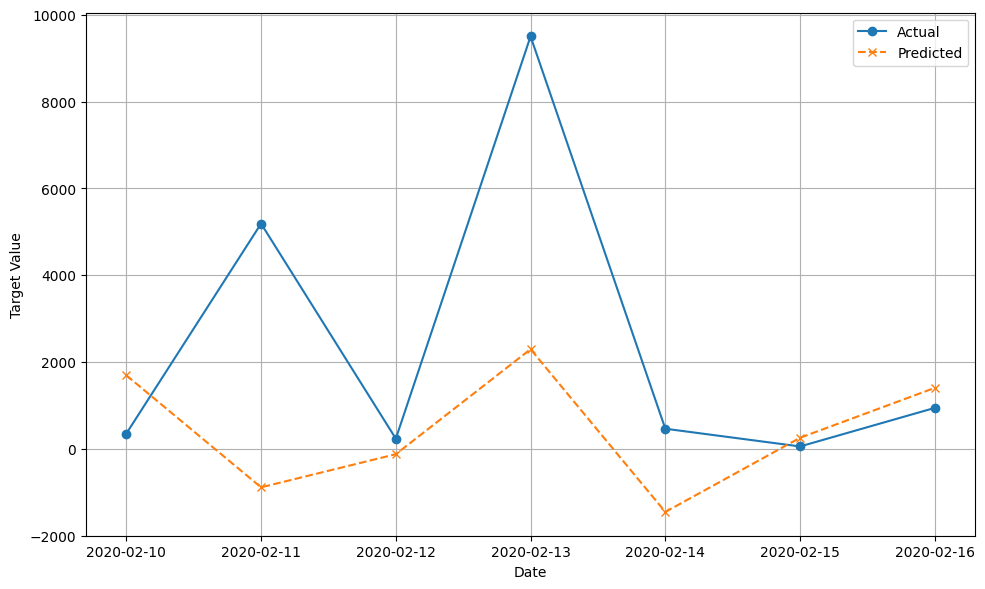


Fold 1 (727 train / 7 test)
MAE: 2508.341, RMSE: 3677.769, R2: -0.207
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 6.22e-05 | test_loss: 1.34e-01 | reg: 6.32e+01 | : 100%|█| 100/100 [01:33<00:00,  1.08


saving model version 0.1


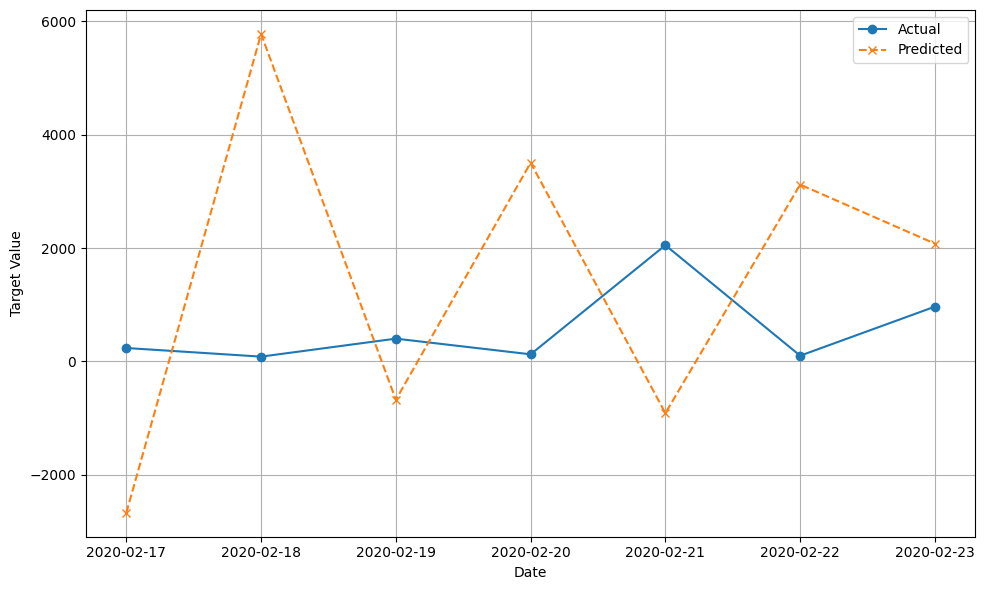


Fold 2 (734 train / 7 test)
MAE: 2879.459, RMSE: 3220.578, R2: -22.099
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.74e-05 | test_loss: 1.30e-01 | reg: 6.35e+01 | : 100%|█| 100/100 [01:43<00:00,  1.04


saving model version 0.1


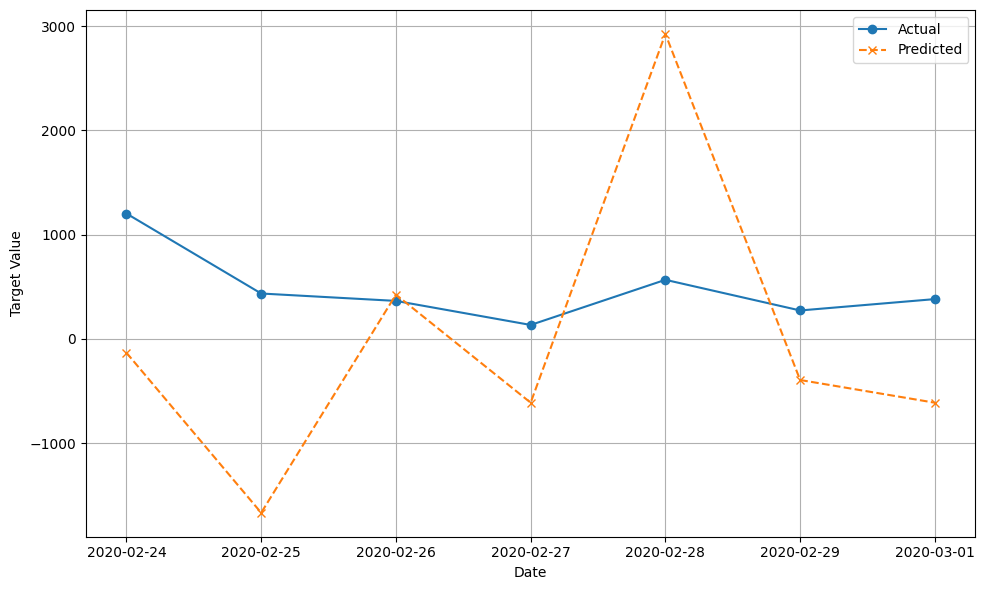


Fold 3 (741 train / 7 test)
MAE: 1180.330, RMSE: 1401.885, R2: -18.185
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.02e-04 | test_loss: 1.30e-01 | reg: 6.31e+01 | : 100%|█| 100/100 [01:32<00:00,  1.08


saving model version 0.1


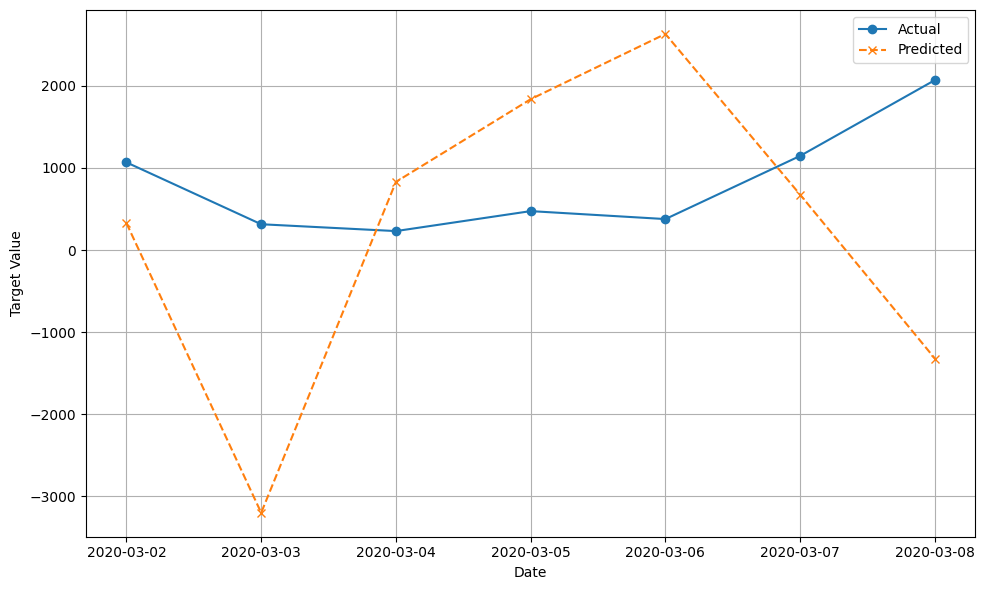


Fold 4 (748 train / 7 test)
MAE: 1762.447, RMSE: 2135.811, R2: -11.054
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.25e-05 | test_loss: 1.35e-01 | reg: 6.28e+01 | : 100%|█| 100/100 [01:41<00:00,  1.02


saving model version 0.1


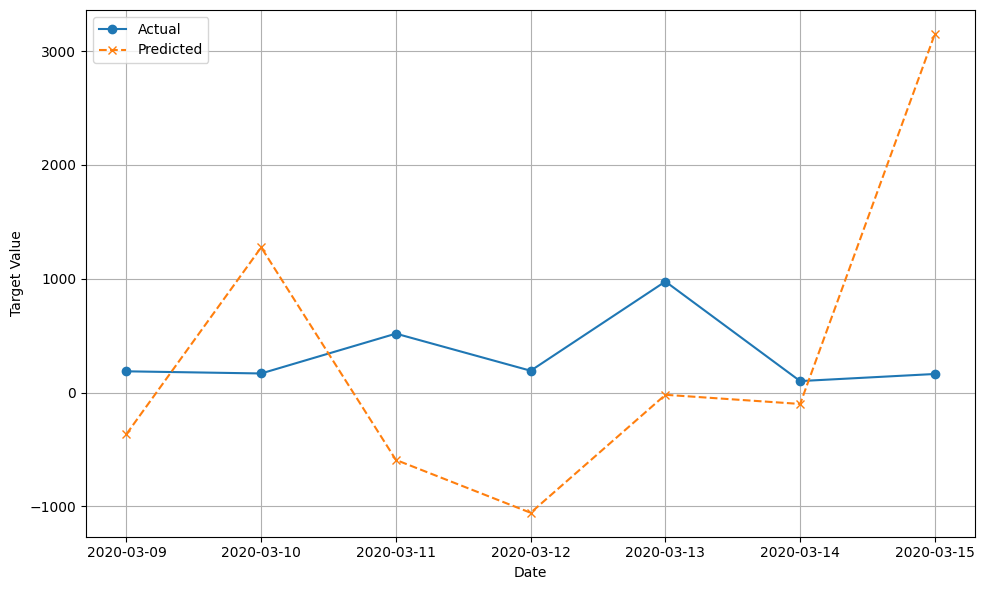


Fold 5 (755 train / 7 test)
MAE: 1171.367, RMSE: 1427.925, R2: -22.858

Average Metrics Across Folds:
MAE: 1900.389
RMSE: 2372.794
R2: -14.881
Temporal Cross-Validation Results:
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.77e-07 | test_loss: 1.37e-01 | reg: 6.22e+01 | : 100%|█| 100/100 [01:52<00:00,  1.13


saving model version 0.1


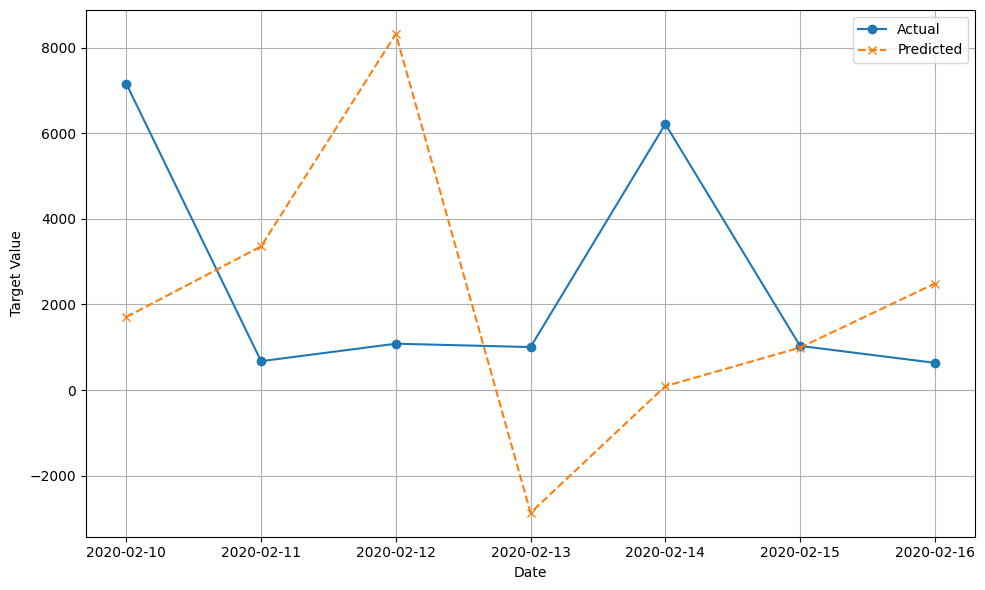


Fold 1 (739 train / 7 test)
MAE: 3891.476, RMSE: 4551.885, R2: -1.983
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.05e-07 | test_loss: 1.20e-01 | reg: 6.22e+01 | : 100%|█| 100/100 [01:56<00:00,  1.16


saving model version 0.1


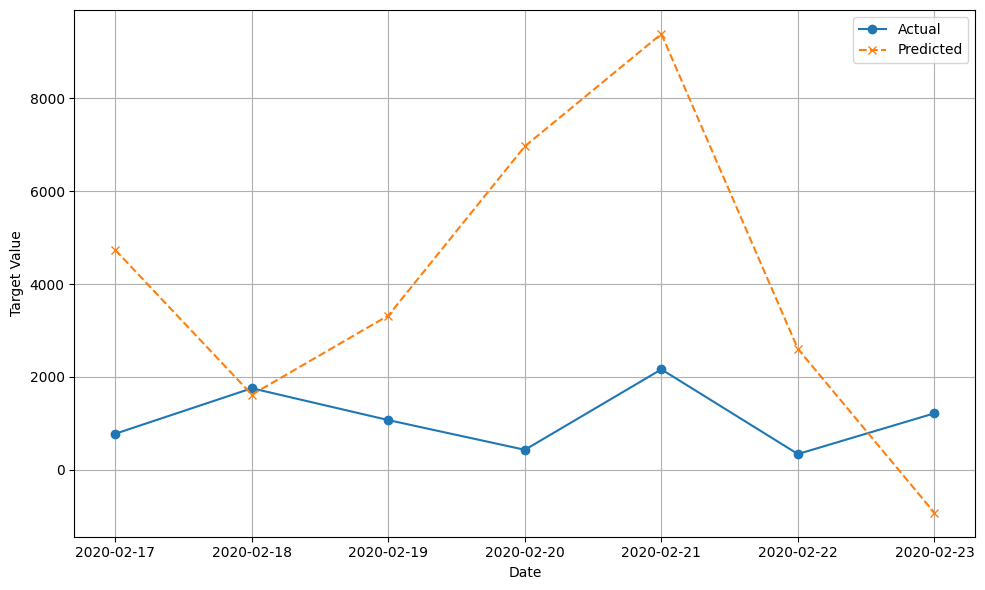


Fold 2 (746 train / 7 test)
MAE: 3502.313, RMSE: 4232.589, R2: -45.333
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.79e-07 | test_loss: 1.23e-01 | reg: 6.21e+01 | : 100%|█| 100/100 [01:58<00:00,  1.19


saving model version 0.1


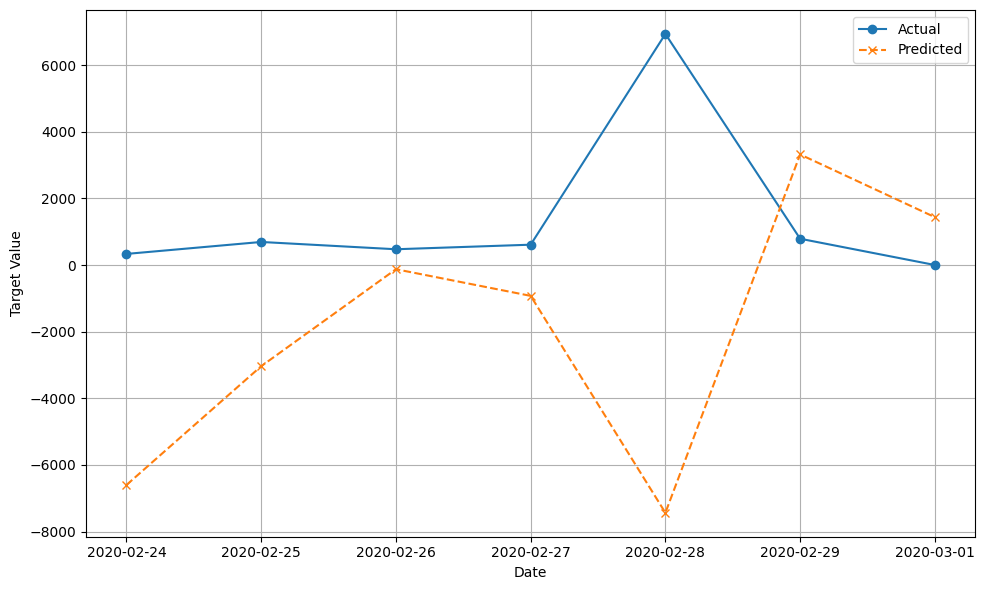


Fold 3 (753 train / 7 test)
MAE: 4448.815, RMSE: 6322.580, R2: -6.749
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.77e-07 | test_loss: 1.12e-01 | reg: 6.23e+01 | : 100%|█| 100/100 [02:14<00:00,  1.35


saving model version 0.1


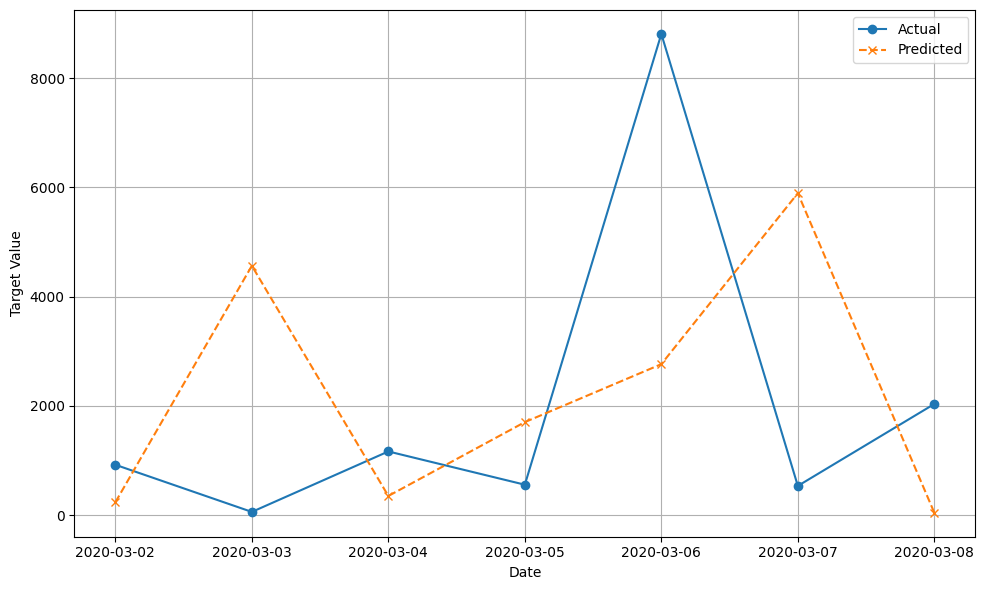


Fold 4 (760 train / 7 test)
MAE: 2935.275, RMSE: 3624.550, R2: -0.636
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.85e-07 | test_loss: 1.16e-01 | reg: 6.22e+01 | : 100%|█| 100/100 [02:05<00:00,  1.26


saving model version 0.1


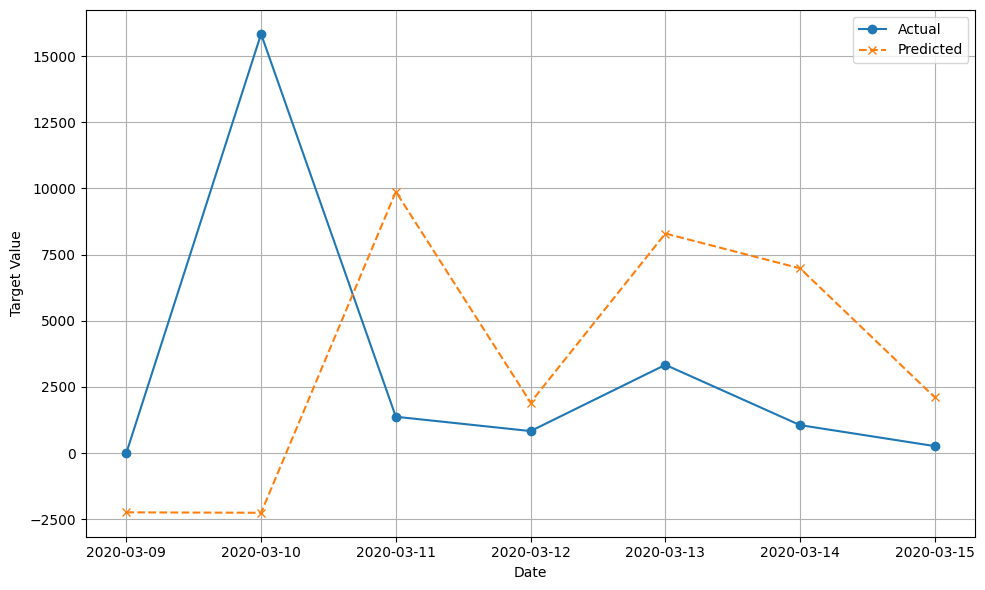


Fold 5 (767 train / 7 test)
MAE: 6094.158, RMSE: 8188.044, R2: -1.441

Average Metrics Across Folds:
MAE: 4174.408
RMSE: 5383.930
R2: -11.229
Temporal Cross-Validation Results:
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.10e-07 | test_loss: 5.45e-02 | reg: 5.46e+01 | : 100%|█| 100/100 [01:59<00:00,  1.19


saving model version 0.1


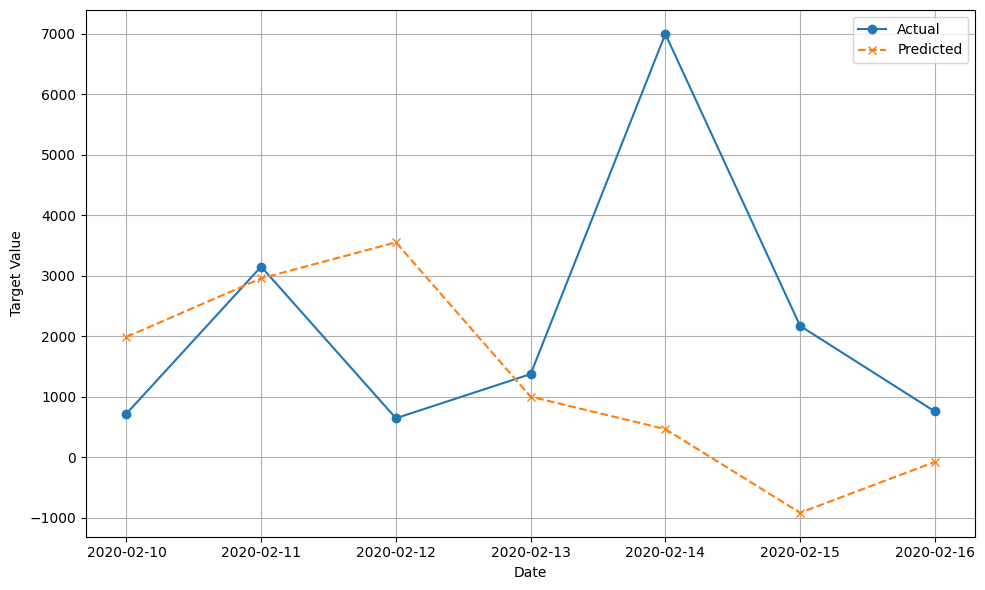


Fold 1 (715 train / 7 test)
MAE: 2170.413, RMSE: 3002.187, R2: -1.020
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 9.35e-08 | test_loss: 6.21e-02 | reg: 5.50e+01 | : 100%|█| 100/100 [01:56<00:00,  1.17


saving model version 0.1


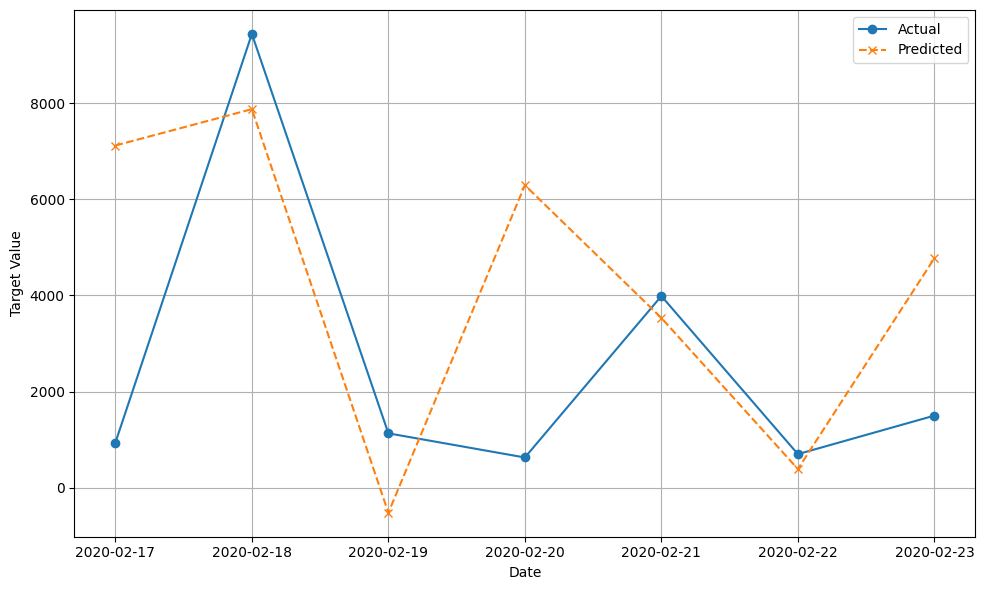


Fold 2 (722 train / 7 test)
MAE: 2730.631, RMSE: 3517.493, R2: -0.388
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 8.53e-08 | test_loss: 5.98e-02 | reg: 5.50e+01 | : 100%|█| 100/100 [01:47<00:00,  1.07


saving model version 0.1


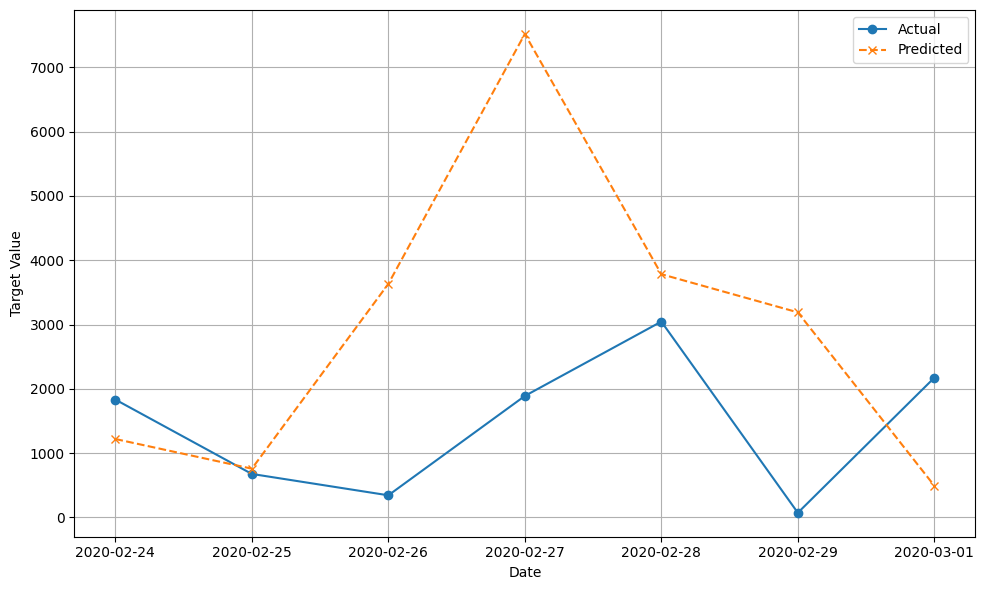


Fold 3 (729 train / 7 test)
MAE: 2164.221, RMSE: 2828.111, R2: -6.855
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 9.74e-08 | test_loss: 4.72e-02 | reg: 5.50e+01 | : 100%|█| 100/100 [01:47<00:00,  1.07


saving model version 0.1


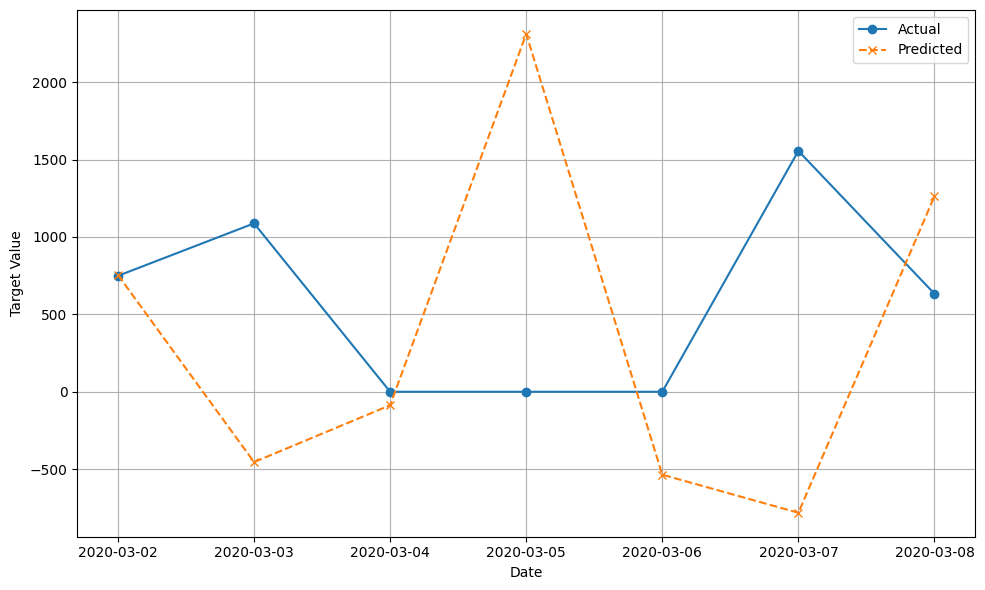


Fold 4 (736 train / 7 test)
MAE: 1064.415, RMSE: 1408.323, R2: -5.167
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 6.78e-08 | test_loss: 5.12e-02 | reg: 5.47e+01 | : 100%|█| 100/100 [01:58<00:00,  1.19


saving model version 0.1


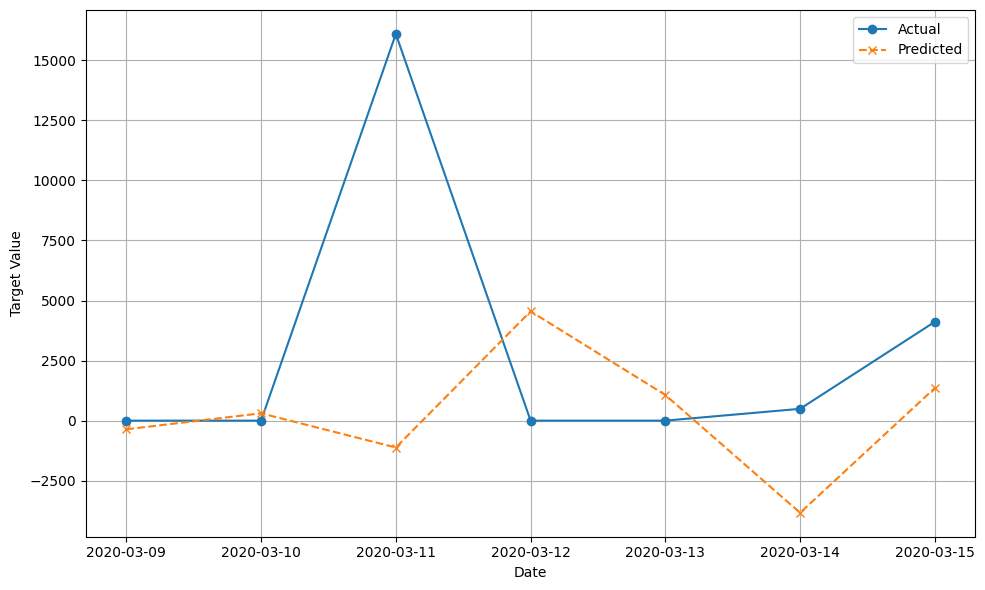


Fold 5 (743 train / 7 test)
MAE: 4368.019, RMSE: 7016.560, R2: -0.603

Average Metrics Across Folds:
MAE: 2499.540
RMSE: 3554.535
R2: -2.806


In [15]:
metrics_1, models_1 = evaluate_model_on_clients(data, [2736675, 1926324, 207417])

In [8]:
metrics_1

[{'avg_MAE': 1926.2428396410262,
  'avg_MSE': 6701860.700928871,
  'avg_RMSE': 2408.7923411418233,
  'avg_R2': -16.033687073180925,
  'avg_mae_ratio': 2.9207492451246115},
 {'avg_MAE': 4279.829704899379,
  'avg_MSE': 32577952.479438193,
  'avg_RMSE': 5475.786146023701,
  'avg_R2': -13.348876688876464,
  'avg_mae_ratio': 2.3357311033715282},
 {'avg_MAE': 2499.539838936942,
  'avg_MSE': 16119917.769825283,
  'avg_RMSE': 3554.534882086573,
  'avg_R2': -2.806307918451503,
  'avg_mae_ratio': 1.368170426255778}]

Temporal Cross-Validation Results:
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.35e-07 | test_loss: 1.07e-01 | reg: 6.06e+01 | : 100%|█| 100/100 [01:01<00:00,  1.64


saving model version 0.1


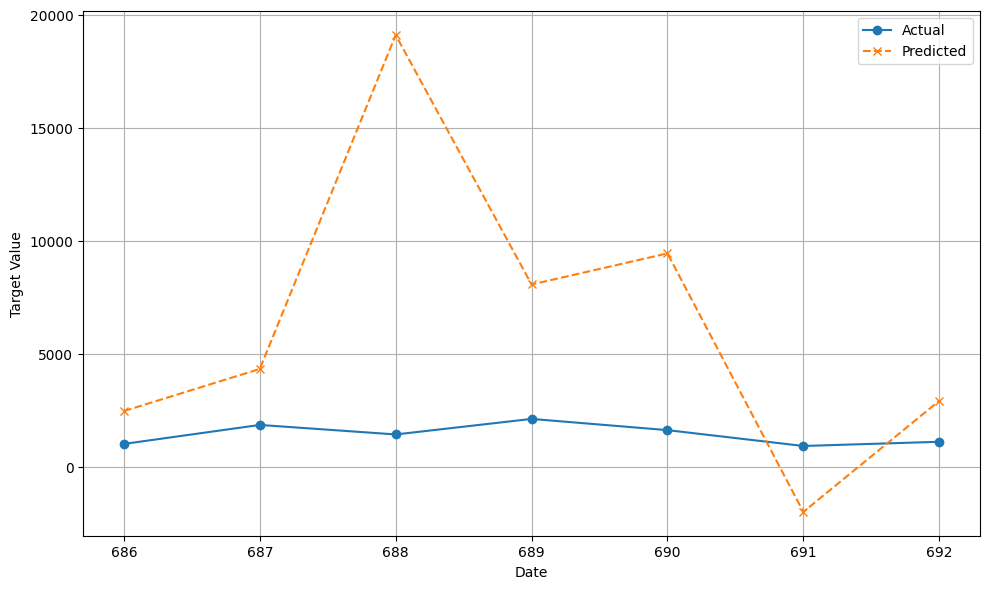


Fold 1 (656 train / 7 test)
MAE: 5726.283, RMSE: 7824.460, R2: -348.548
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.72e-07 | test_loss: 1.04e-01 | reg: 6.01e+01 | : 100%|█| 100/100 [01:11<00:00,  1.40


saving model version 0.1


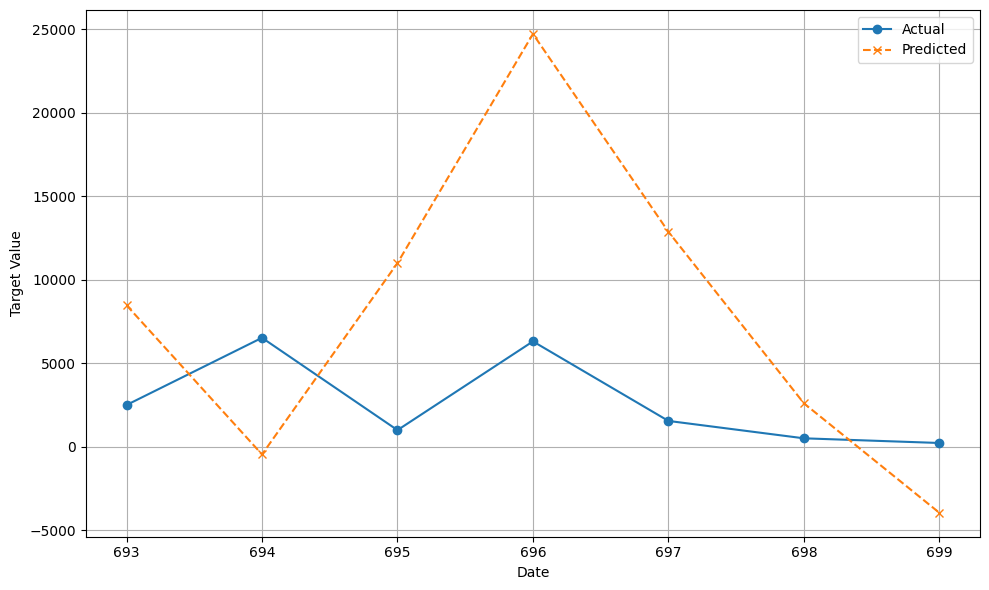


Fold 2 (663 train / 7 test)
MAE: 8426.521, RMSE: 9811.808, R2: -14.719
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.33e-07 | test_loss: 1.14e-01 | reg: 6.03e+01 | : 100%|█| 100/100 [01:14<00:00,  1.35


saving model version 0.1


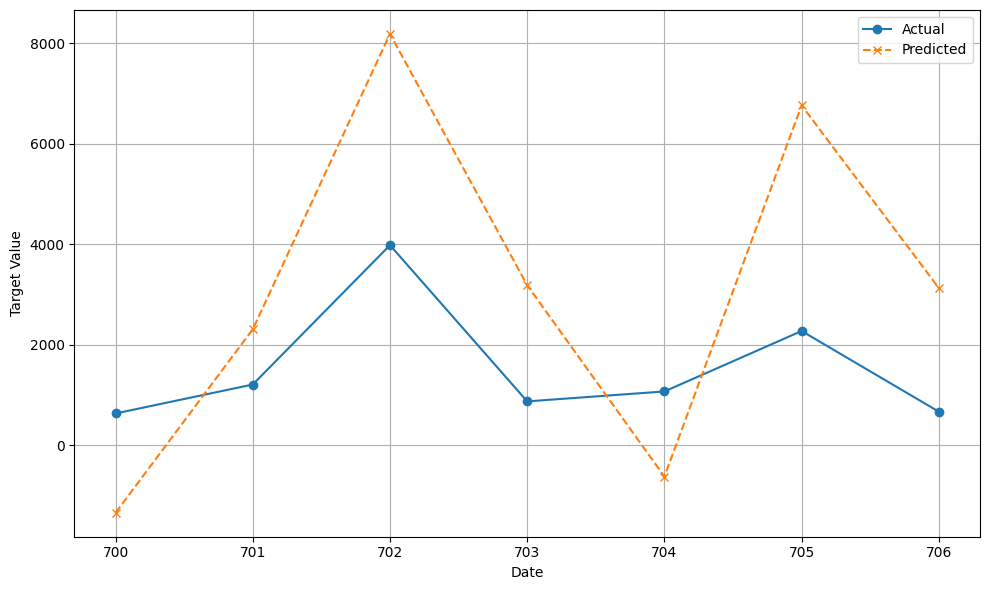


Fold 3 (670 train / 7 test)
MAE: 2606.006, RMSE: 2859.828, R2: -5.458
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.01e-07 | test_loss: 1.17e-01 | reg: 6.09e+01 | : 100%|█| 100/100 [01:15<00:00,  1.33


saving model version 0.1


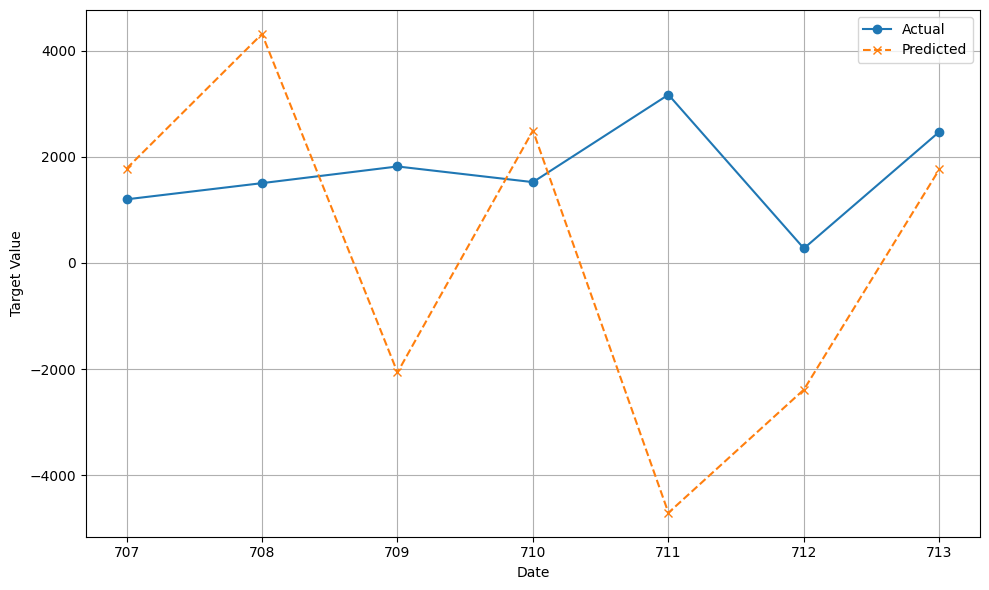


Fold 4 (677 train / 7 test)
MAE: 2783.518, RMSE: 3661.357, R2: -17.317
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.43e-07 | test_loss: 1.19e-01 | reg: 6.09e+01 | : 100%|█| 100/100 [01:15<00:00,  1.32


saving model version 0.1


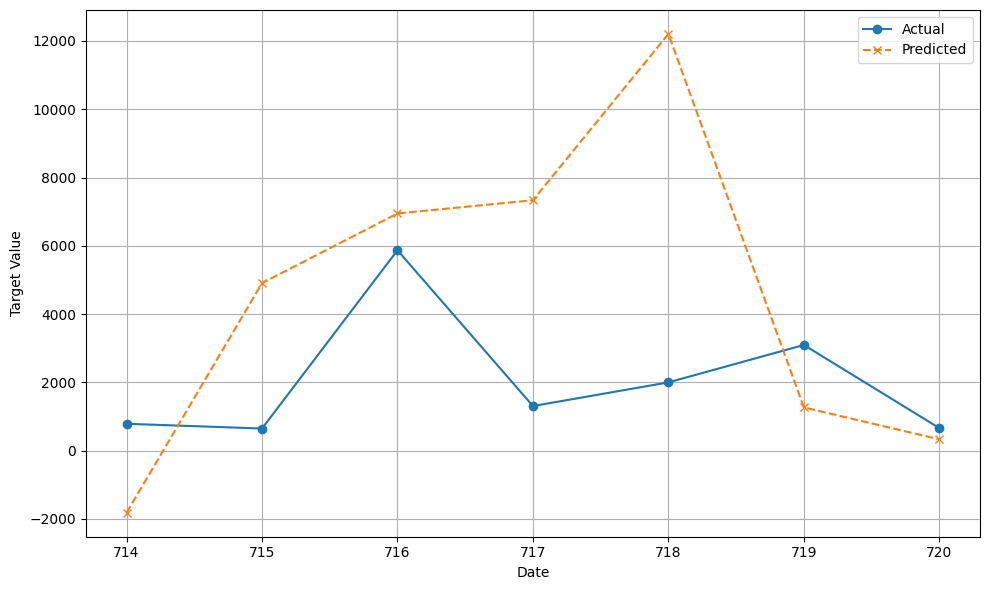


Fold 5 (684 train / 7 test)
MAE: 3762.646, RMSE: 4929.017, R2: -6.825

Average Metrics Across Folds:
MAE: 4660.995
RMSE: 5817.294
R2: -78.573
Temporal Cross-Validation Results:
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 8.34e-08 | test_loss: 5.77e-02 | reg: 5.82e+01 | : 100%|█| 100/100 [01:19<00:00,  1.25


saving model version 0.1


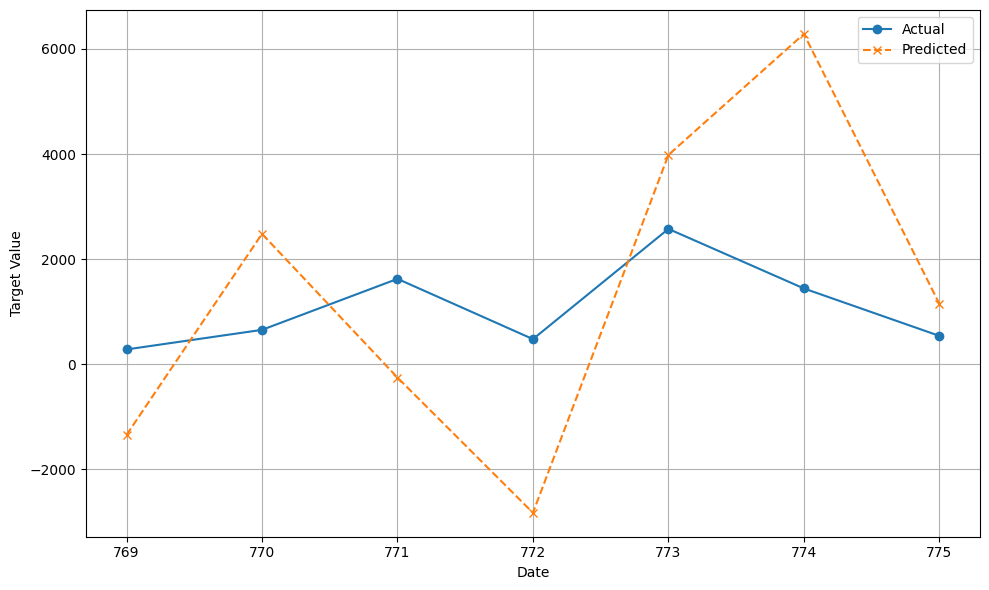


Fold 1 (739 train / 7 test)
MAE: 2213.541, RMSE: 2569.594, R2: -10.181
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.49e-07 | test_loss: 6.09e-02 | reg: 5.87e+01 | : 100%|█| 100/100 [01:11<00:00,  1.41


saving model version 0.1


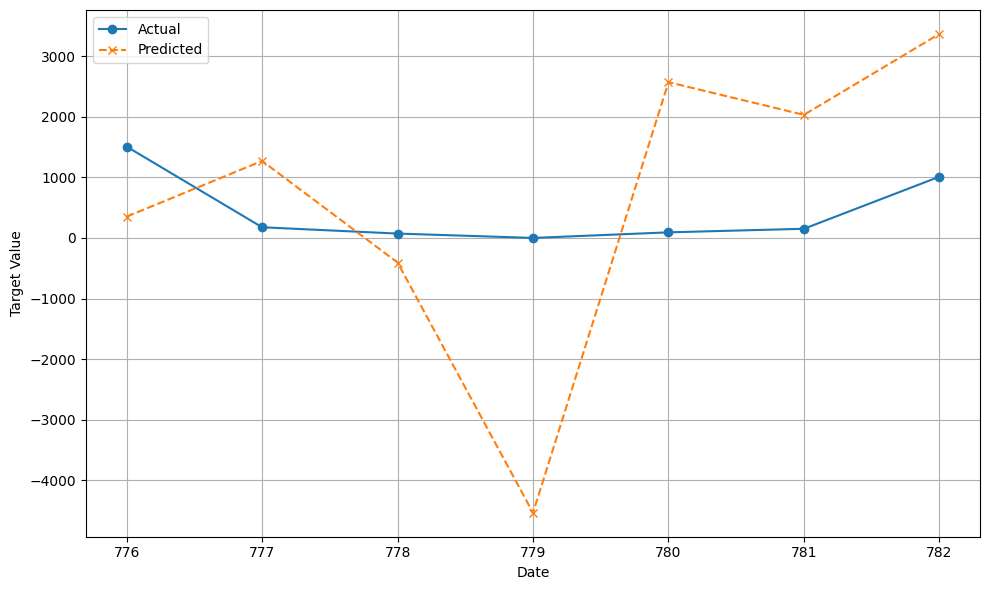


Fold 2 (746 train / 7 test)
MAE: 1996.558, RMSE: 2346.769, R2: -17.667
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.11e-07 | test_loss: 5.78e-02 | reg: 5.85e+01 | : 100%|█| 100/100 [01:19<00:00,  1.25


saving model version 0.1


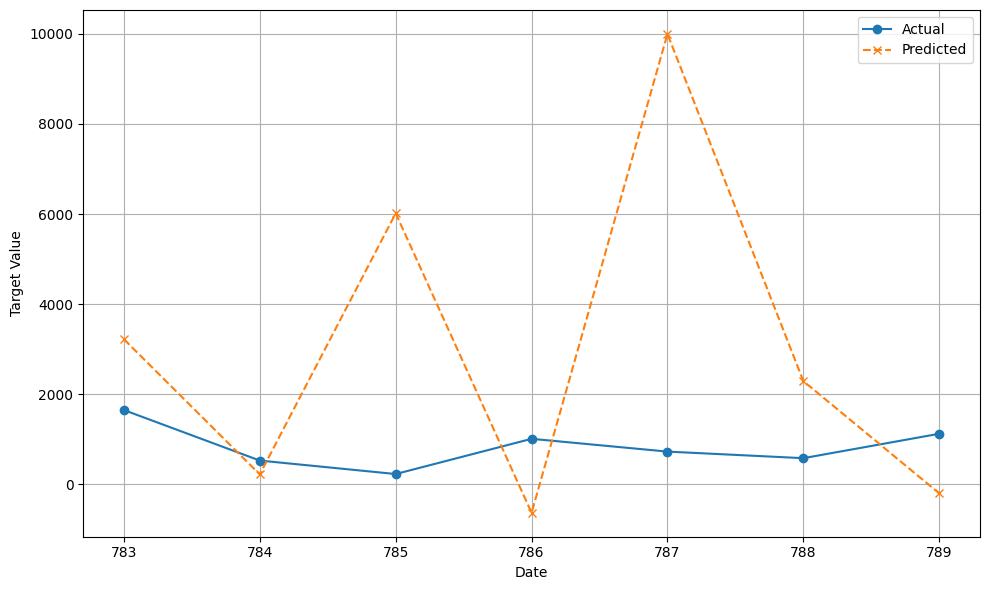


Fold 3 (753 train / 7 test)
MAE: 3086.774, RMSE: 4298.244, R2: -97.411
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 8.21e-08 | test_loss: 6.40e-02 | reg: 5.84e+01 | : 100%|█| 100/100 [01:25<00:00,  1.17


saving model version 0.1


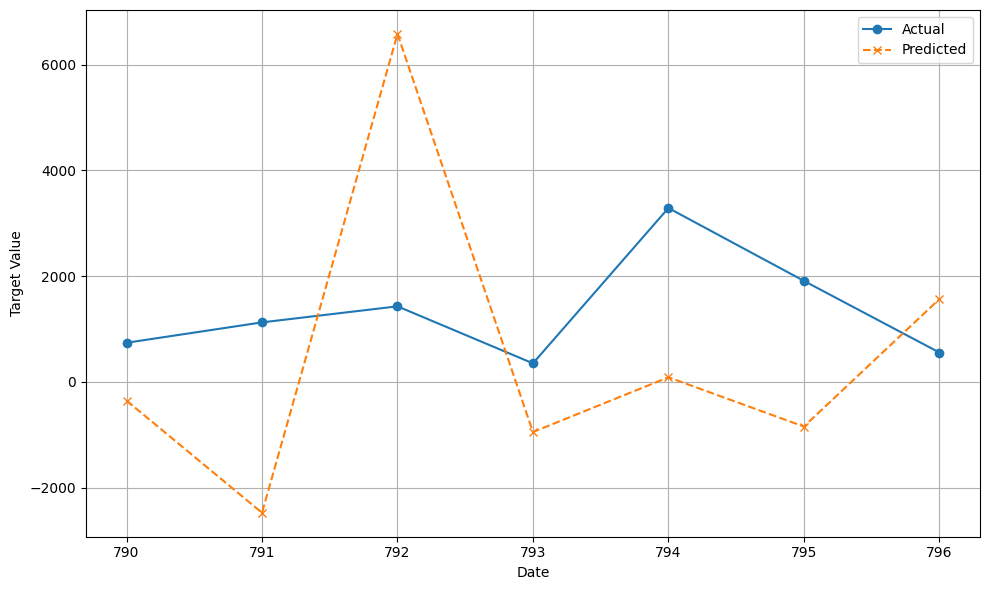


Fold 4 (760 train / 7 test)
MAE: 2587.808, RMSE: 2958.380, R2: -8.993
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.48e-07 | test_loss: 5.95e-02 | reg: 5.83e+01 | : 100%|█| 100/100 [01:25<00:00,  1.17


saving model version 0.1


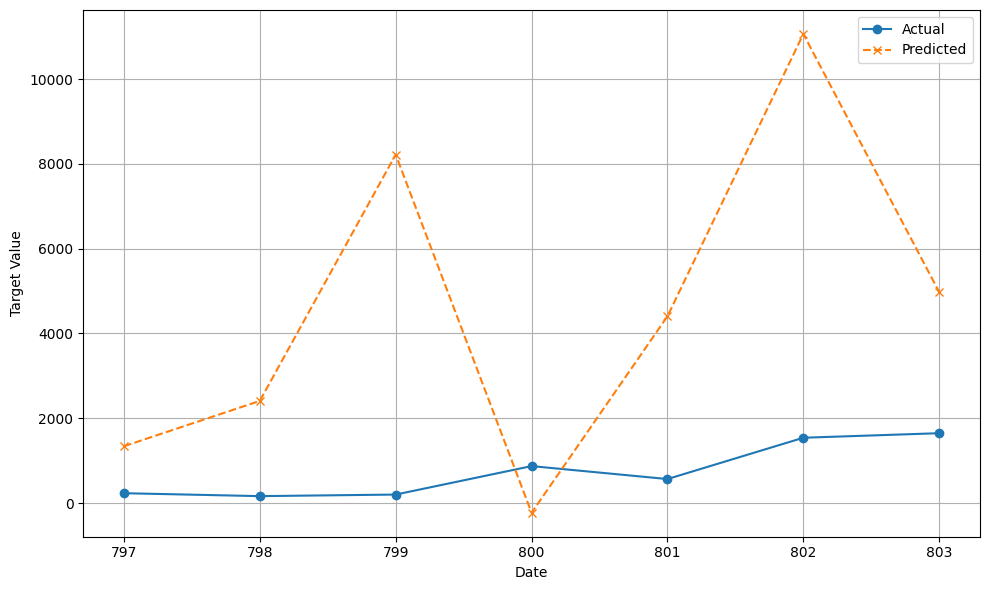


Fold 5 (767 train / 7 test)
MAE: 4167.123, RMSE: 5187.681, R2: -77.677

Average Metrics Across Folds:
MAE: 2810.361
RMSE: 3472.134
R2: -42.386
Temporal Cross-Validation Results:
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 6.54e-08 | test_loss: 3.48e-02 | reg: 5.46e+01 | : 100%|█| 100/100 [01:26<00:00,  1.15


saving model version 0.1


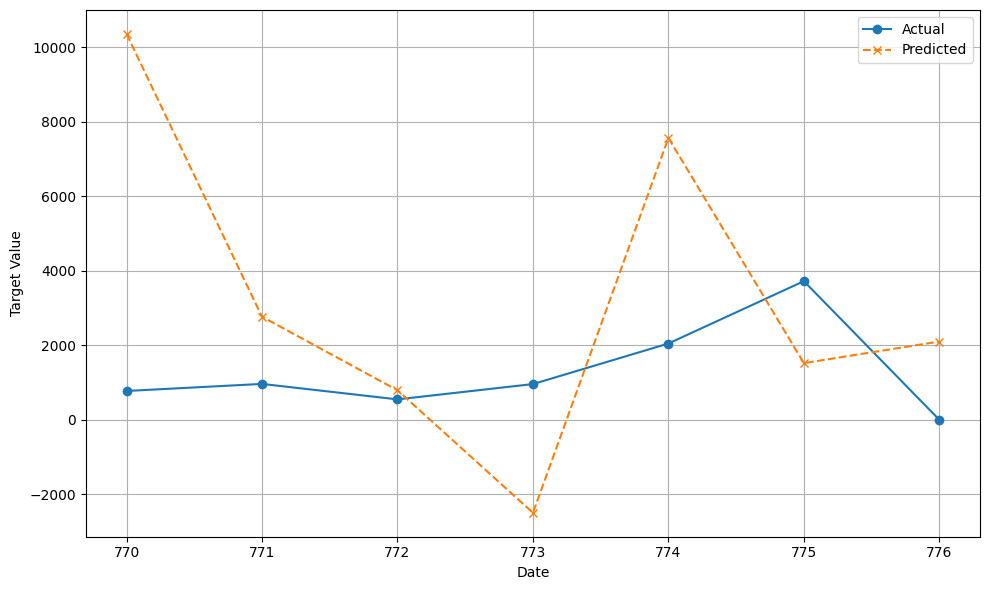


Fold 1 (740 train / 7 test)
MAE: 3557.126, RMSE: 4578.514, R2: -14.985
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 8.24e-08 | test_loss: 3.48e-02 | reg: 5.49e+01 | : 100%|█| 100/100 [01:24<00:00,  1.18


saving model version 0.1


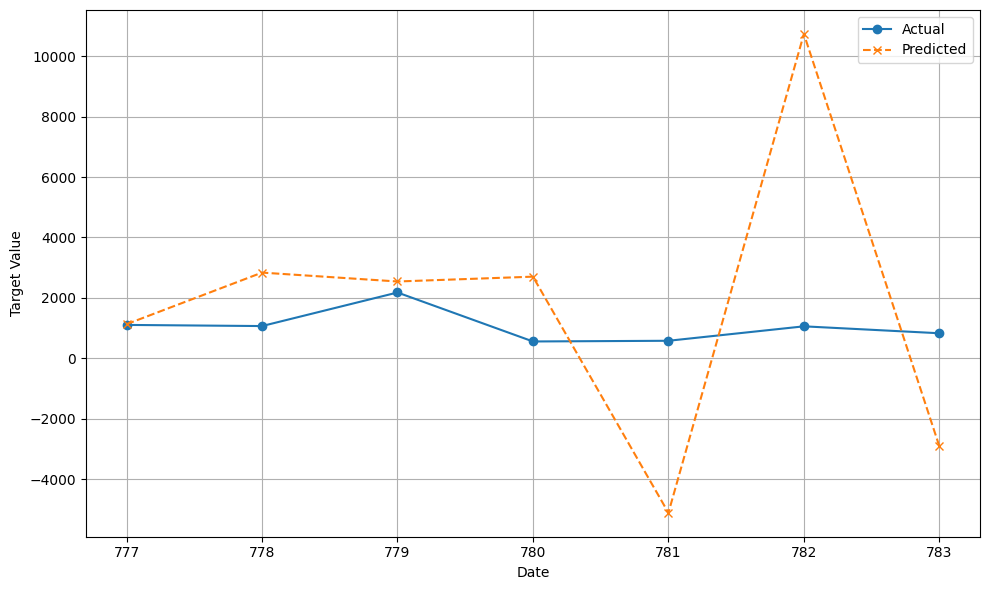


Fold 2 (747 train / 7 test)
MAE: 3345.147, RMSE: 4597.176, R2: -81.720
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 6.31e-08 | test_loss: 3.25e-02 | reg: 5.45e+01 | : 100%|█| 100/100 [01:23<00:00,  1.20


saving model version 0.1


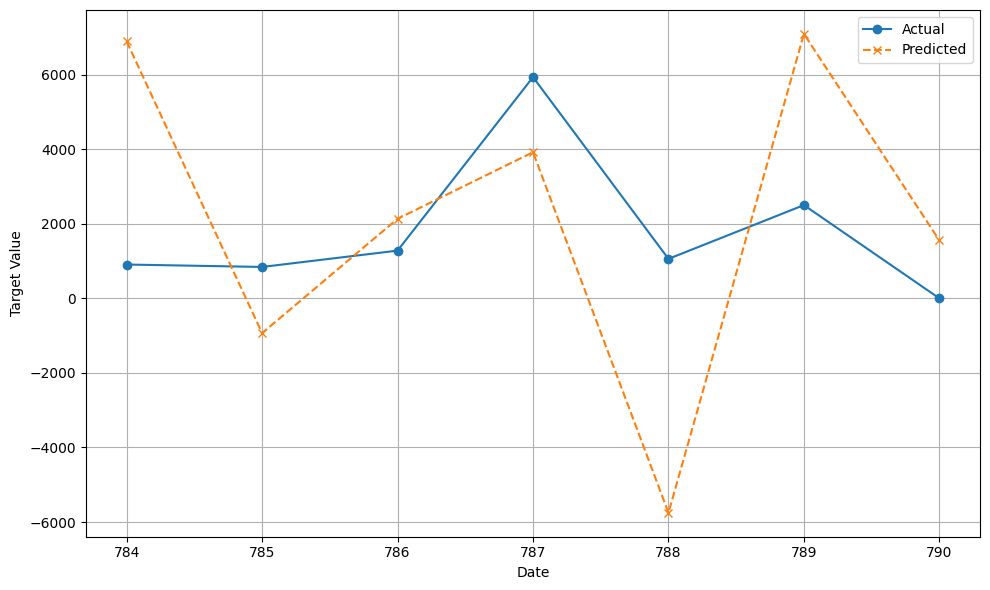


Fold 3 (754 train / 7 test)
MAE: 3368.209, RMSE: 4028.170, R2: -3.864
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 6.13e-08 | test_loss: 3.33e-02 | reg: 5.45e+01 | : 100%|█| 100/100 [01:28<00:00,  1.13


saving model version 0.1


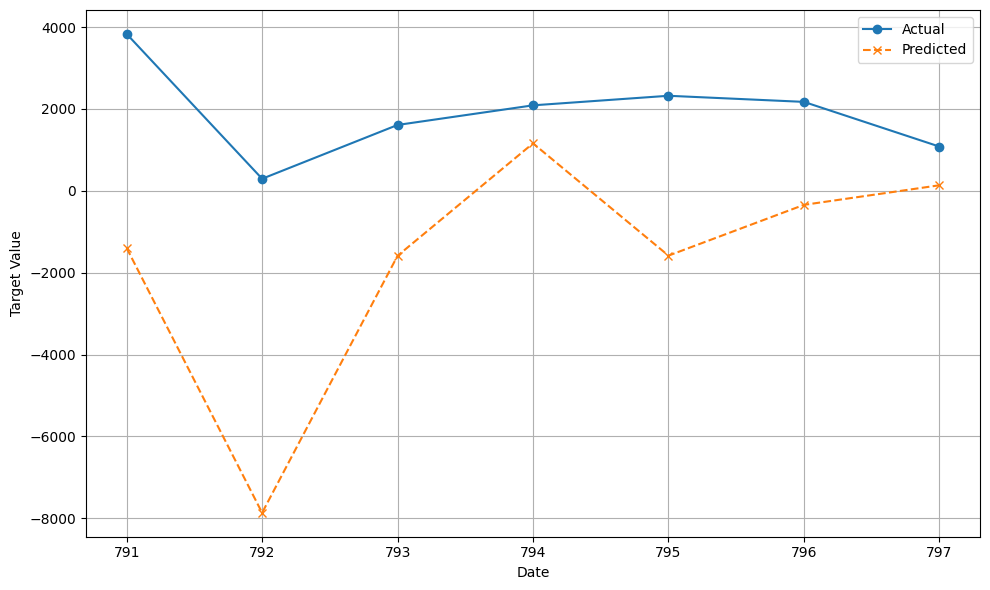


Fold 4 (761 train / 7 test)
MAE: 3553.451, RMSE: 4266.459, R2: -16.337
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 8.42e-08 | test_loss: 3.34e-02 | reg: 5.44e+01 | : 100%|█| 100/100 [01:30<00:00,  1.11


saving model version 0.1


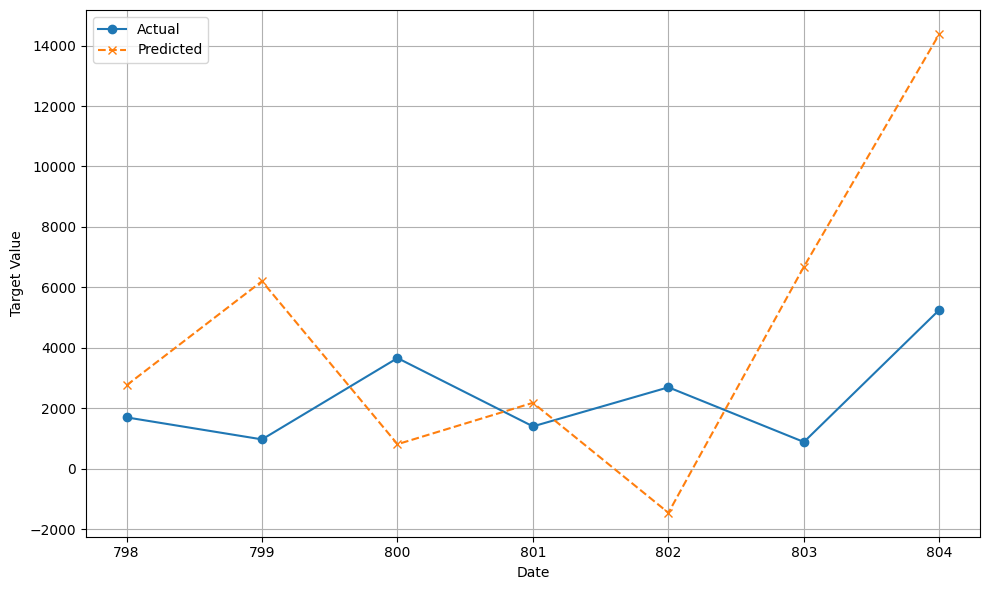


Fold 5 (768 train / 7 test)
MAE: 4144.088, RMSE: 4949.504, R2: -9.940

Average Metrics Across Folds:
MAE: 3593.604
RMSE: 4483.965
R2: -25.369
Temporal Cross-Validation Results:
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.04e-07 | test_loss: 5.66e-02 | reg: 5.67e+01 | : 100%|█| 100/100 [01:24<00:00,  1.18


saving model version 0.1


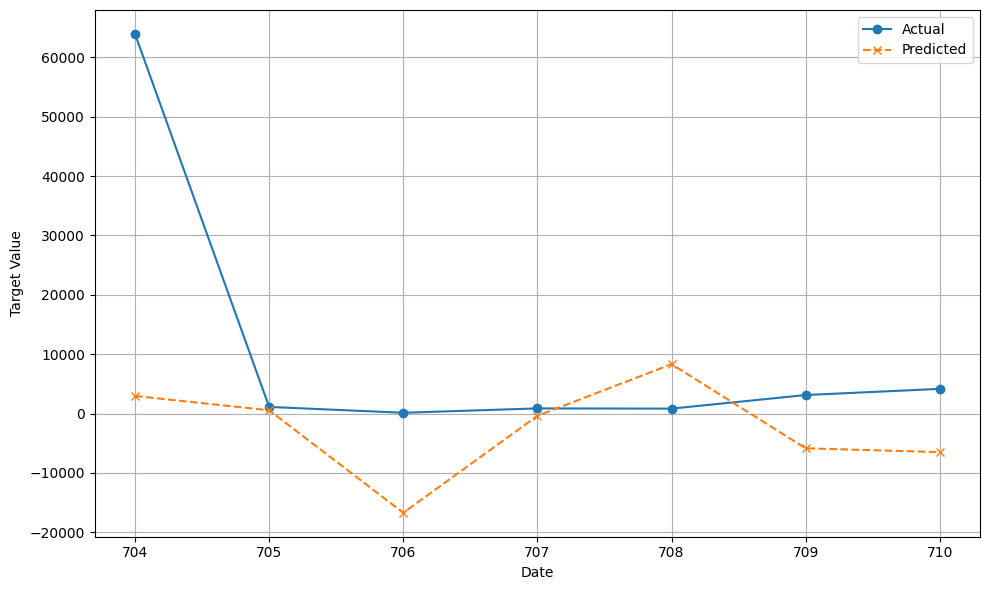


Fold 1 (674 train / 7 test)
MAE: 15245.433, RMSE: 24644.181, R2: -0.277
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.88e-07 | test_loss: 9.77e-02 | reg: 5.61e+01 | : 100%|█| 100/100 [01:24<00:00,  1.19


saving model version 0.1


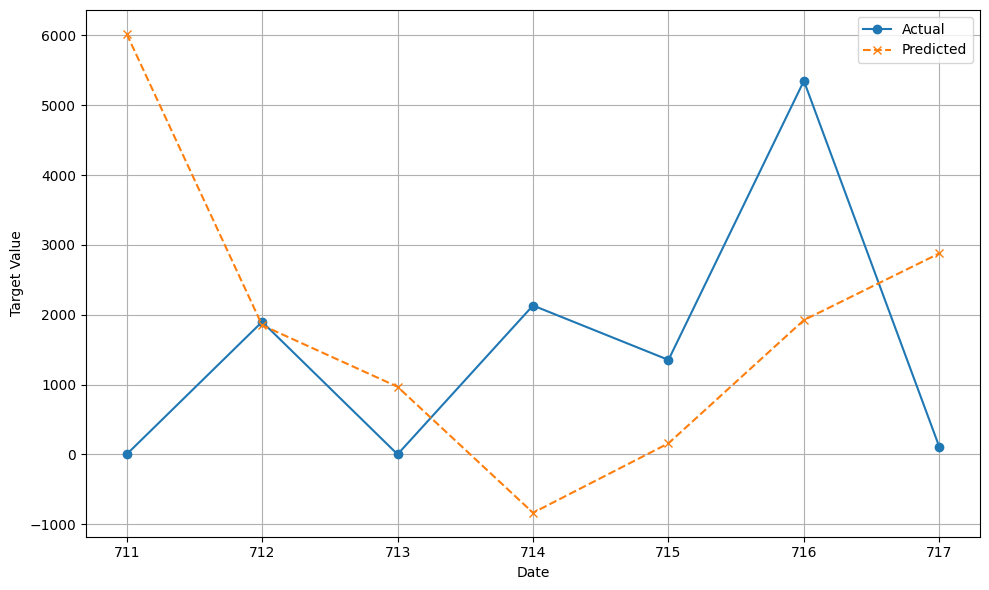


Fold 2 (681 train / 7 test)
MAE: 2485.751, RMSE: 3090.490, R2: -2.064
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.81e-07 | test_loss: 9.79e-02 | reg: 5.65e+01 | : 100%|█| 100/100 [01:25<00:00,  1.16


saving model version 0.1


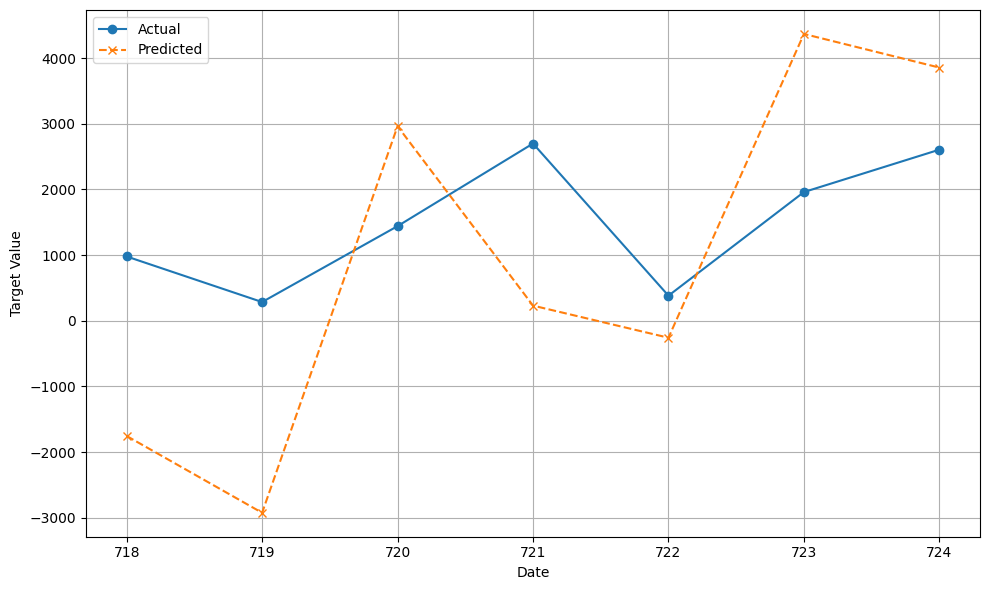


Fold 3 (688 train / 7 test)
MAE: 2033.114, RMSE: 2202.411, R2: -4.785
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.06e-07 | test_loss: 1.01e-01 | reg: 5.65e+01 | : 100%|█| 100/100 [01:31<00:00,  1.10


saving model version 0.1


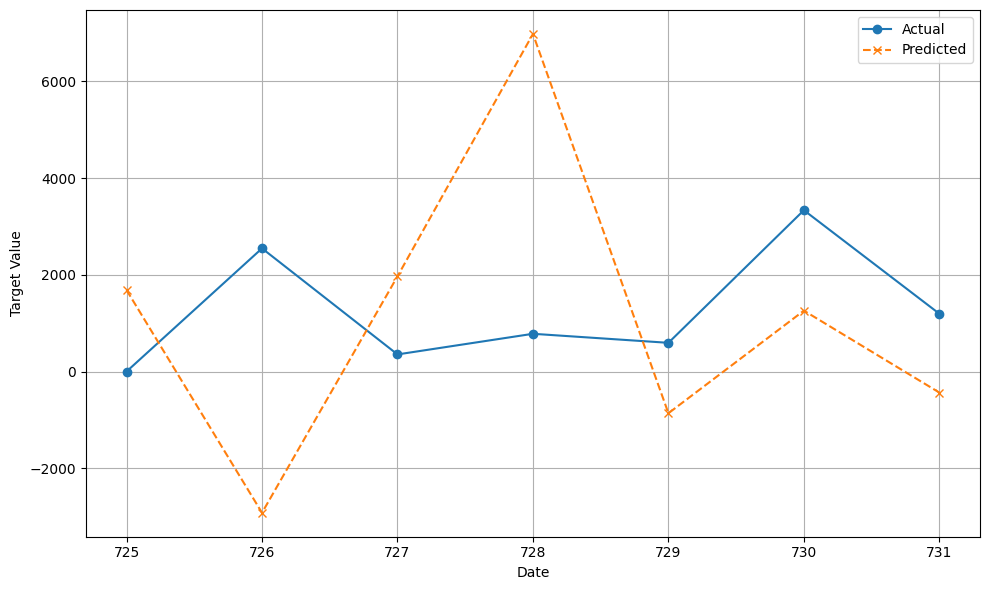


Fold 4 (695 train / 7 test)
MAE: 2876.770, RMSE: 3442.162, R2: -8.156
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.46e-07 | test_loss: 9.79e-02 | reg: 5.68e+01 | : 100%|█| 100/100 [01:32<00:00,  1.08


saving model version 0.1


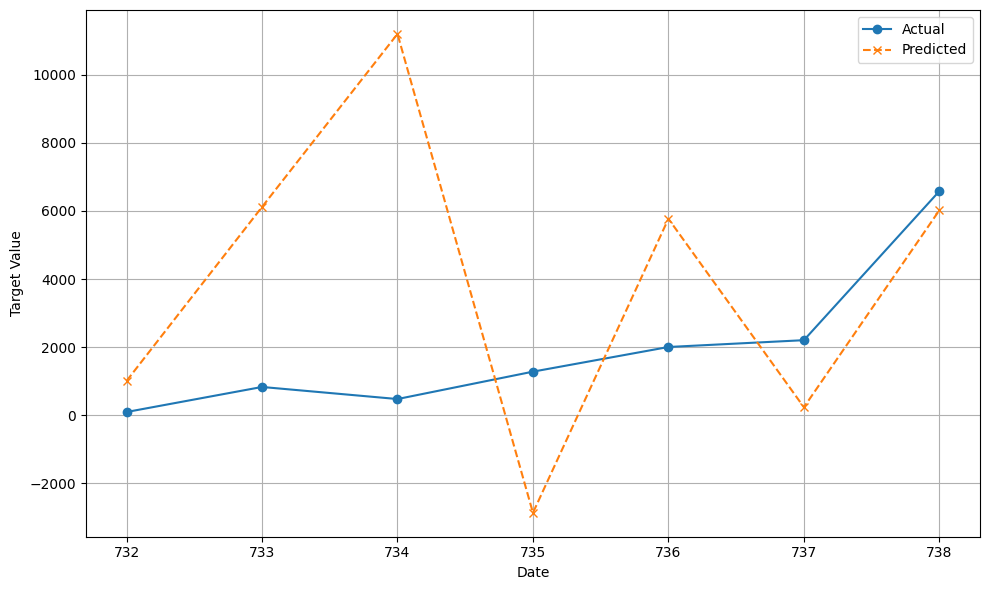


Fold 5 (702 train / 7 test)
MAE: 3907.898, RMSE: 5059.659, R2: -5.220

Average Metrics Across Folds:
MAE: 5309.793
RMSE: 7687.781
R2: -4.100
Temporal Cross-Validation Results:
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.35e-07 | test_loss: 1.13e-01 | reg: 6.22e+01 | : 100%|█| 100/100 [01:29<00:00,  1.11


saving model version 0.1


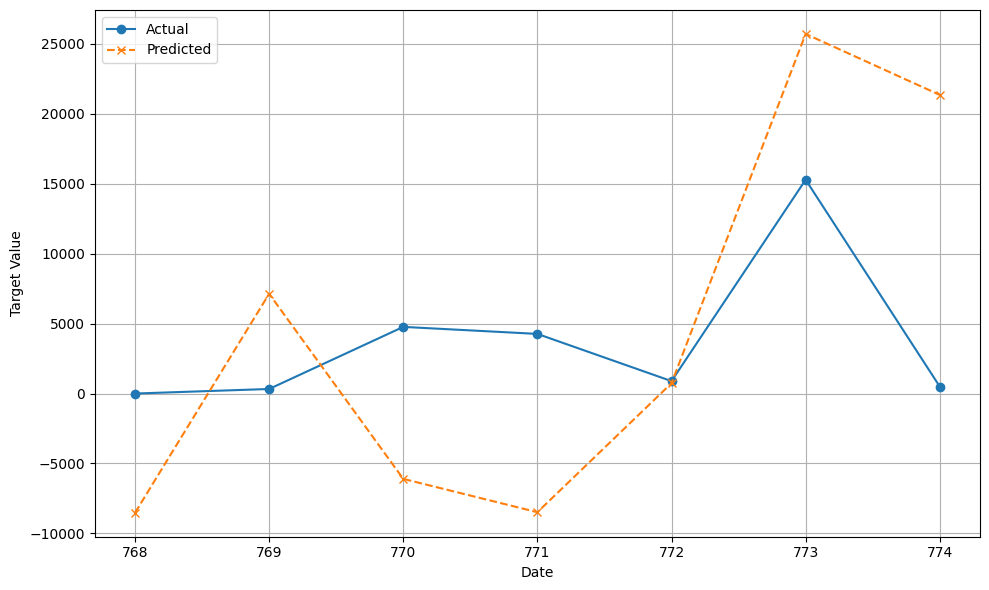


Fold 1 (738 train / 7 test)
MAE: 10053.890, RMSE: 11608.003, R2: -4.271
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.24e-07 | test_loss: 1.03e-01 | reg: 6.19e+01 | : 100%|█| 100/100 [01:29<00:00,  1.12


saving model version 0.1


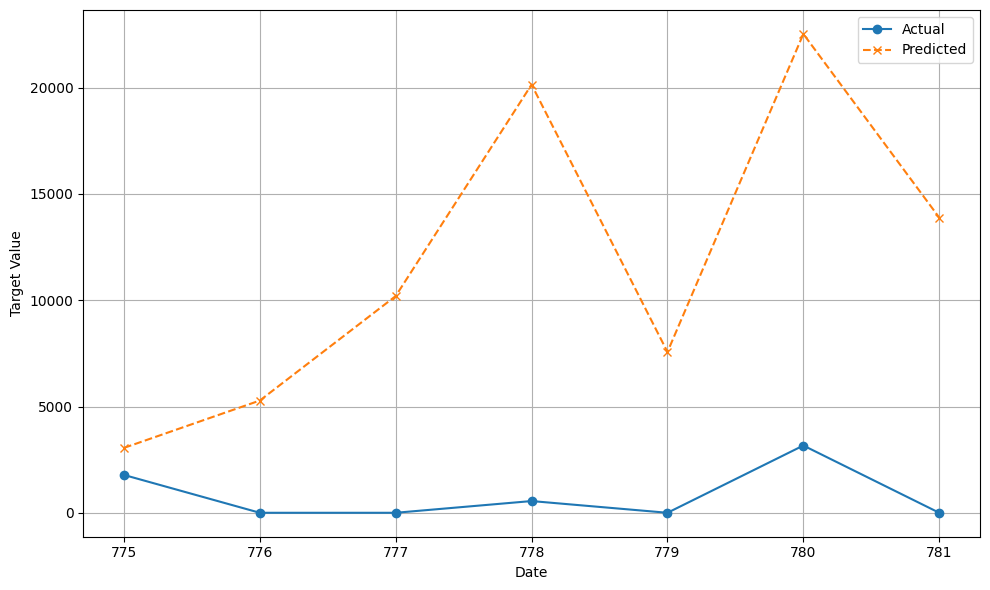


Fold 2 (745 train / 7 test)
MAE: 11023.194, RMSE: 12775.756, R2: -123.553
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.00e-07 | test_loss: 1.16e-01 | reg: 6.17e+01 | : 100%|█| 100/100 [01:34<00:00,  1.06


saving model version 0.1


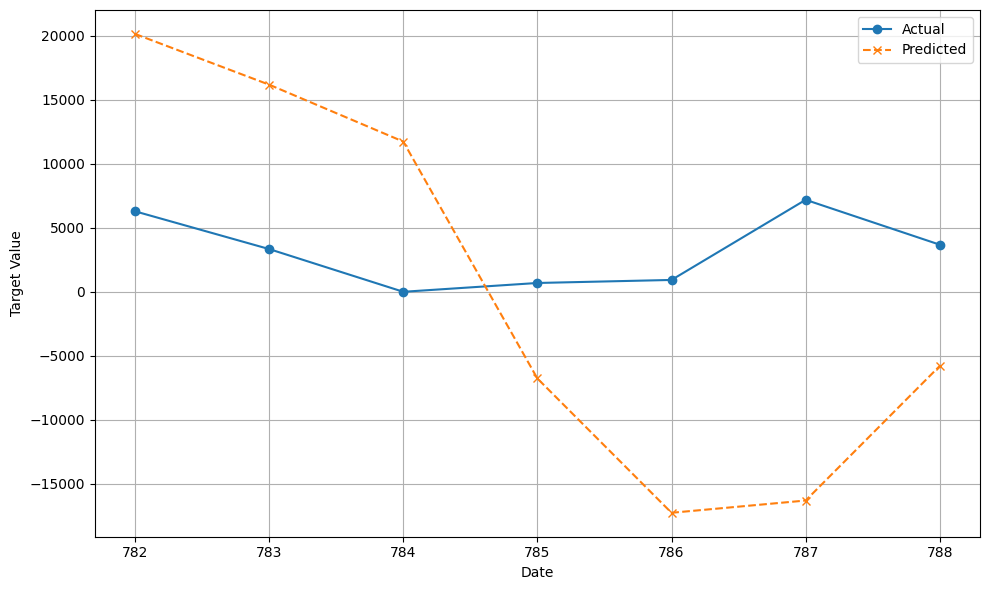


Fold 3 (752 train / 7 test)
MAE: 13868.627, RMSE: 14754.045, R2: -31.133
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.12e-07 | test_loss: 1.21e-01 | reg: 6.19e+01 | : 100%|█| 100/100 [01:28<00:00,  1.13


saving model version 0.1


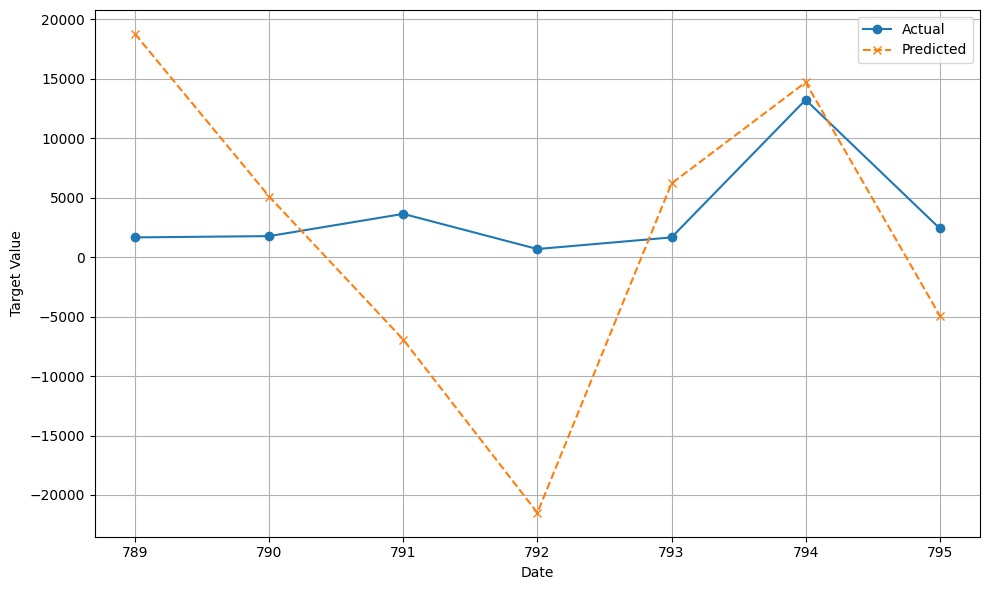


Fold 4 (759 train / 7 test)
MAE: 9502.458, RMSE: 11854.718, R2: -7.665
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.80e-07 | test_loss: 1.07e-01 | reg: 6.15e+01 | : 100%|█| 100/100 [01:36<00:00,  1.04


saving model version 0.1


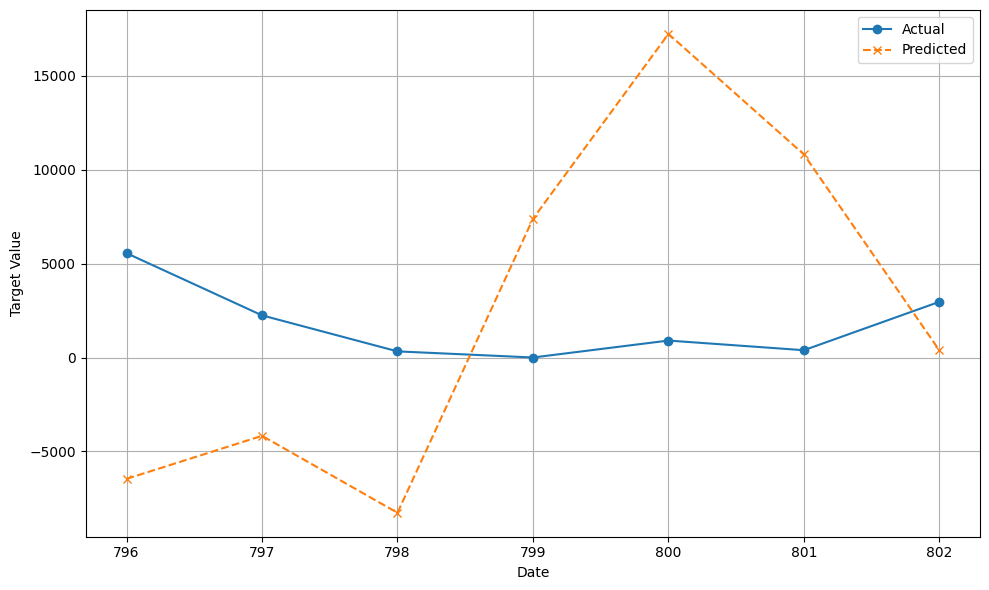


Fold 5 (766 train / 7 test)
MAE: 9105.054, RMSE: 9968.774, R2: -28.171

Average Metrics Across Folds:
MAE: 10710.645
RMSE: 12192.259
R2: -38.958


In [9]:
metrics_2, models_2 = evaluate_model_on_clients(data, [3377993, 1597439, 1662478, 3002740, 2853439])

In [10]:
metrics_2

[{'avg_MAE': 4660.99479711914,
  'avg_MSE': 40674620.78571485,
  'avg_RMSE': 5817.293935769588,
  'avg_R2': -78.57338347587383,
  'avg_mae_ratio': 2.455979713777322},
 {'avg_MAE': 2810.360767735073,
  'avg_MSE': 13249816.896423347,
  'avg_RMSE': 3472.1335627603194,
  'avg_R2': -42.38589848578452,
  'avg_mae_ratio': 3.5767943997870275},
 {'avg_MAE': 3593.60423386928,
  'avg_MSE': 20204647.144320652,
  'avg_RMSE': 4483.9646455852035,
  'avg_R2': -25.36928440695179,
  'avg_mae_ratio': 2.285422933964997},
 {'avg_MAE': 5309.793039847237,
  'avg_MSE': 131837211.00458837,
  'avg_RMSE': 7687.7807516884295,
  'avg_R2': -4.100247085209803,
  'avg_mae_ratio': 1.746587431155394},
 {'avg_MAE': 10710.644595179965,
  'avg_MSE': 151111663.82713765,
  'avg_RMSE': 12192.25922613756,
  'avg_R2': -38.95843549261086,
  'avg_mae_ratio': 5.787148305838428}]

In [16]:
models_2

[[KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1])],
 [KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1])],
 [KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1])],
 [KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANFo

In [13]:
metrics = metrics_1 + metrics_2

In [14]:
metrics

[{'avg_MAE': 1772.7723431222098,
  'avg_MSE': 11117883.343112404,
  'avg_RMSE': 2953.6220140883843,
  'avg_R2': -0.6412909040959887},
 {'avg_MAE': 1111.3486246686664,
  'avg_MSE': 1946978.546636733,
  'avg_RMSE': 1332.6772605869548,
  'avg_R2': -3.174836113675687},
 {'avg_MAE': 2024.6234803728378,
  'avg_MSE': 29832372.899216127,
  'avg_RMSE': 3530.8302127456336,
  'avg_R2': -185.31313533527498},
 {'avg_MAE': 580.0894906529018,
  'avg_MSE': 4137437.4678407535,
  'avg_RMSE': 1186.0506109057933,
  'avg_R2': -2.6807417309589163},
 {'avg_MAE': 1910.5126842912946,
  'avg_MSE': 6970809.171694127,
  'avg_RMSE': 2458.232982918387,
  'avg_R2': -8.942691779054812},
 {'avg_MAE': 1941.1422993164065,
  'avg_MSE': 11911102.365762526,
  'avg_RMSE': 3073.685263924096,
  'avg_R2': -0.8405820363765354},
 {'avg_MAE': 1127.7653530970983,
  'avg_MSE': 1963704.9711875722,
  'avg_RMSE': 1345.747567206628,
  'avg_R2': -3.5318980351999714},
 {'avg_MAE': 2090.408909537179,
  'avg_MSE': 30054416.341416784,
  'av

In [16]:
sum_metrics = {key: 0.0 for key in metrics[0]}
    
for metric_dict in metrics:
    for key, value in metric_dict.items():
        sum_metrics[key] += value

mean_metrics = {
    key: total / len(metrics)
    for key, total in sum_metrics.items()
}

In [17]:
mean_metrics

{'avg_MAE': 2298.3882059278617,
 'avg_MSE': 77500782.59526981,
 'avg_RMSE': 4020.449123679056,
 'avg_R2': -46.58416692316559}

In [18]:
models_1

[[KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1])],
 [KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1])],
 [KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1]),
  KANForecaster(grid=7, steps=100, width=[15, 25, 1])]]

In [35]:
model = models_2[0][2].kan

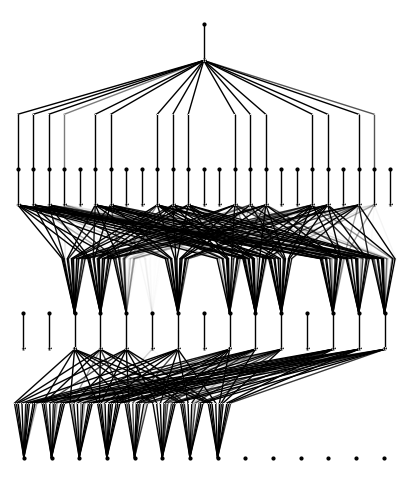

In [23]:
model.plot()

In [36]:
model = model.prune(edge_th=1e-2)

saving model version 0.2


In [37]:
model.auto_symbolic()
sf = model.symbolic_formula()[0][0]

fixing (0,0,0) with 0, r2=0.0, c=0
fixing (0,0,1) with 0, r2=0.0, c=0
fixing (0,0,2) with 0, r2=0.0, c=0
fixing (0,0,3) with 0, r2=0.0, c=0
fixing (0,0,4) with 0, r2=0.0, c=0
fixing (0,0,5) with 0, r2=0.0, c=0
fixing (0,0,6) with 0, r2=0.0, c=0
fixing (0,0,7) with 0, r2=0.0, c=0
fixing (0,0,8) with 0, r2=0.0, c=0
fixing (0,0,9) with 0, r2=0.0, c=0
fixing (0,0,10) with 0, r2=0.0, c=0
fixing (0,0,11) with 0, r2=0.0, c=0
fixing (0,0,12) with 0, r2=0.0, c=0
fixing (0,0,13) with 0, r2=0.0, c=0
fixing (0,0,14) with 0, r2=0.0, c=0
fixing (0,1,0) with 0, r2=0.0, c=0
fixing (0,1,1) with 0, r2=0.0, c=0
fixing (0,1,2) with 0, r2=0.0, c=0
fixing (0,1,3) with 0, r2=0.0, c=0
fixing (0,1,4) with 0, r2=0.0, c=0
fixing (0,1,5) with 0
fixing (0,1,6) with 0, r2=0.0, c=0
fixing (0,1,7) with 0, r2=0.0, c=0
fixing (0,1,8) with 0, r2=0.0, c=0
fixing (0,1,9) with 0, r2=0.0, c=0
fixing (0,1,10) with 1/x^2, r2=0.9993069767951965, c=2
fixing (0,1,11) with 0, r2=0.0, c=0
fixing (0,1,12) with 0, r2=0.0, c=0
fixing

fixing (0,13,8) with x, r2=0.9976687431335449, c=1
fixing (0,13,9) with 0, r2=0.0, c=0
fixing (0,13,10) with x, r2=0.9977514743804932, c=1
fixing (0,13,11) with 1/x^2, r2=0.9990830421447754, c=2
fixing (0,13,12) with 0, r2=0.0, c=0
fixing (0,13,13) with x, r2=0.9962061643600464, c=1
fixing (0,13,14) with exp, r2=0.9999496936798096, c=2
fixing (0,14,0) with exp, r2=0.9994289875030518, c=2
fixing (0,14,1) with exp, r2=0.999981701374054, c=2
fixing (0,14,2) with x, r2=0.9501426219940186, c=1
fixing (0,14,3) with exp, r2=0.9999688267707825, c=2
fixing (0,14,4) with exp, r2=0.9984400868415833, c=2
fixing (0,14,5) with exp, r2=0.9997456073760986, c=2
fixing (0,14,6) with 0, r2=0.0, c=0
fixing (0,14,7) with x, r2=0.9969525933265686, c=1
fixing (0,14,8) with x, r2=0.9794679284095764, c=1
fixing (0,14,9) with exp, r2=0.9997023940086365, c=2
fixing (0,14,10) with x, r2=0.9717233777046204, c=1
fixing (0,14,11) with x, r2=0.9930007457733154, c=1
fixing (0,14,12) with x^2, r2=0.9999013543128967, c=

fixing (1,7,2) with 0, r2=0.0, c=0
fixing (1,7,3) with 0, r2=0.0, c=0
fixing (1,7,4) with 0, r2=0.0, c=0
fixing (1,7,5) with 0, r2=0.0, c=0
fixing (1,7,6) with x, r2=0.9785603880882263, c=1
fixing (1,7,7) with 0, r2=0.0, c=0
fixing (1,7,8) with 0, r2=0.0, c=0
fixing (1,7,9) with 0, r2=0.0, c=0
fixing (1,7,10) with x, r2=0.9512590169906616, c=1
fixing (1,7,11) with 0, r2=0.0, c=0
fixing (1,7,12) with 0, r2=0.0, c=0
fixing (1,7,13) with 0, r2=0.0, c=0
fixing (1,7,14) with 0, r2=0.0, c=0
fixing (1,7,15) with x, r2=0.9791774749755859, c=1
fixing (1,7,16) with x, r2=0.9909663200378418, c=1
fixing (1,7,17) with 0, r2=0.0, c=0
fixing (1,7,18) with 0, r2=0.0, c=0
fixing (1,7,19) with 0, r2=0.0, c=0
fixing (1,7,20) with 0, r2=0.0, c=0
fixing (1,7,21) with 0, r2=0.0, c=0
fixing (1,7,22) with 0, r2=0.0, c=0
fixing (1,7,23) with 0, r2=0.0, c=0
fixing (1,7,24) with 0, r2=0.0, c=0
fixing (1,8,0) with exp, r2=0.9995235204696655, c=2
fixing (1,8,1) with x, r2=0.9813786149024963, c=1
fixing (1,8,2) wit

fixing (2,13,0) with 0, r2=0.0, c=0
fixing (2,14,0) with 0, r2=0.0, c=0
fixing (2,15,0) with 0, r2=0.0, c=0
fixing (2,16,0) with 0, r2=0.0, c=0
fixing (2,17,0) with 0, r2=0.0, c=0
fixing (2,18,0) with 0, r2=0.0, c=0
fixing (2,19,0) with 0, r2=0.0, c=0
fixing (2,20,0) with 0, r2=0.0, c=0
fixing (2,21,0) with 0, r2=0.0, c=0
fixing (2,22,0) with 0, r2=0.0, c=0
fixing (2,23,0) with 0, r2=0.0, c=0
fixing (2,24,0) with 0, r2=0.0, c=0
saving model version 0.3


In [47]:
nsimplify(ex_round(ex_round(sf, 5),5))

1541/25000 + 1/(24964*(977*x_11/50000 + 5081*x_14/100000 + 171*x_15/10000 + 2163*(-66019*x_13/100000 - 1)**2/50000 - 2363*(-x_15 - 29723/100000)**2/100000 - exp(10*x_10)/2304 + 152*exp(1493*x_12/2500)/3125 + 70*exp(587*x_12/1250)/757 + 1501*exp(x_13/3)/20000 + 39441*exp(-13197*x_11/100000 + 539*x_15/20000 + 3*(-98477*x_13/100000 - 1)**2/563 + 19101*exp(19*x_12/56)/100000 + 5991*exp(171*x_14/500)/50000)/100000 - 1041*exp(-41027*x_11/25000 + 3319*x_12/10000 + 15389*x_14/10000 - 84011*(-76101*x_13/100000 - 1)**2/100000 + 43*exp(245550012588501*x_10/25000000000000)/2000 + 31747*exp(309*x_15/250)/50000)/50000 - 7061*exp(-22431*x_12/100000 - 4409*x_13/25000 + 2652*x_14/3125 + 33157*x_15/100000 - 391*exp(13510000705719*x_10/2500000000000)/25000 - 17987*exp(-16853*x_11/3125)/100000 - 4/(133225*(7223/100000 - x_2)**2))/100000 - 1 + 14861/(50000*(-1281*x_11/10000 + exp(8*x_10)/1444 - 18927*exp(2771*x_13/6250)/100000 + 7261*exp(2227*x_15/2500)/100000 - 1)**2))**2)

In [42]:
sf

0.061637952021556 + 3.73231091144678e-5/(0.0195397879960124*x_11 + 0.0508088748205055*x_14 + 0.0170972736727379*x_15 + 0.0432588483789232*(-0.660188337264637*x_13 - 1)**2 - 0.0236326054913672*(-x_15 - 0.297229671163118)**2 - 0.000441862861764008*exp(10.0*x_10) + 0.0924660435082404*exp(0.469599574804306*x_12) + 0.0486416232403337*exp(0.5971999168396*x_12) + 0.0750457268031112*exp(0.334079653024673*x_13) + 0.394408013088464*exp(-0.131968836795545*x_11 + 0.0269531201291628*x_15 + 0.00533333972279044*(-0.984774904290624*x_13 - 1)**2 + 0.19100639036238*exp(0.339279681444168*x_12) + 0.119815734621005*exp(0.341999679803848*x_14)) - 0.0208195011838284*exp(-1.64107551149097*x_11 + 0.331904662395539*x_12 + 1.53890459387725*x_14 - 0.840105277126051*(-0.761008105881089*x_13 - 1)**2 + 0.021501687853822*exp(9.82200050354004*x_10) + 0.634935883379445*exp(1.23599982261658*x_15)) - 0.0706082023266757*exp(-0.224307152109615*x_12 - 0.176364394048713*x_13 + 0.84863715770108*x_14 + 0.331569136334871*x_15 -

In [68]:
model = models_2[2][1].kan
model = model.prune(edge_th=1e-2)
model.auto_symbolic()
sf = model.symbolic_formula()[0][0]

saving model version 0.2
fixing (0,0,0) with 0, r2=0.0, c=0
fixing (0,0,1) with 0, r2=0.0, c=0
fixing (0,0,2) with 0, r2=0.0, c=0
fixing (0,0,3) with 0, r2=0.0, c=0
fixing (0,0,4) with 0
fixing (0,0,5) with 0, r2=0.0, c=0
fixing (0,0,6) with 1/x^2, r2=0.99760502576828, c=2
fixing (0,0,7) with 0
fixing (0,0,8) with 0, r2=0.0, c=0
fixing (0,0,9) with 0, r2=0.0, c=0
fixing (0,0,10) with 0, r2=0.0, c=0
fixing (0,0,11) with 1/x^2, r2=0.9984166622161865, c=2
fixing (0,0,12) with 0, r2=0.0, c=0
fixing (0,0,13) with 0, r2=0.0, c=0
fixing (0,0,14) with 1/x^2, r2=0.9986026287078857, c=2
fixing (0,1,0) with 0, r2=0.0, c=0
fixing (0,1,1) with 0, r2=0.0, c=0
fixing (0,1,2) with 0, r2=0.0, c=0
fixing (0,1,3) with 0, r2=0.0, c=0
fixing (0,1,4) with 0, r2=0.0, c=0
fixing (0,1,5) with 0, r2=0.0, c=0
fixing (0,1,6) with 0, r2=0.0, c=0
fixing (0,1,7) with 0, r2=0.0, c=0
fixing (0,1,8) with 0, r2=0.0, c=0
fixing (0,1,9) with 0, r2=0.0, c=0
fixing (0,1,10) with 0, r2=0.0, c=0
fixing (0,1,11) with 0, r2=0.0

fixing (0,14,2) with 0, r2=0.0, c=0
fixing (0,14,3) with exp, r2=0.9998065233230591, c=2
fixing (0,14,4) with 0, r2=0.0, c=0
fixing (0,14,5) with x, r2=0.9619709253311157, c=1
fixing (0,14,6) with 0, r2=0.0, c=0
fixing (0,14,7) with 1/x^2, r2=0.9995877146720886, c=2
fixing (0,14,8) with 0, r2=0.0, c=0
fixing (0,14,9) with x, r2=0.9849305748939514, c=1
fixing (0,14,10) with 0, r2=0.0, c=0
fixing (0,14,11) with exp, r2=0.998683512210846, c=2
fixing (0,14,12) with x, r2=0.9915720820426941, c=1
fixing (0,14,13) with x, r2=0.9872925281524658, c=1
fixing (0,14,14) with 0, r2=0.0, c=0
fixing (1,0,0) with 0, r2=0.0, c=0
fixing (1,0,1) with 0, r2=0.0, c=0
fixing (1,0,2) with x, r2=0.960081934928894, c=1
fixing (1,0,3) with x^2, r2=0.9997262358665466, c=2
fixing (1,0,4) with exp, r2=0.9985239505767822, c=2
fixing (1,0,5) with 0, r2=0.0, c=0
fixing (1,0,6) with 0, r2=0.0, c=0
fixing (1,0,7) with 0, r2=0.0, c=0
fixing (1,0,8) with 0, r2=0.0, c=0
fixing (1,0,9) with x, r2=0.974144697189331, c=1
fix

fixing (1,7,13) with 0, r2=0.0, c=0
fixing (1,7,14) with 0, r2=0.0, c=0
fixing (1,7,15) with 0, r2=0.0, c=0
fixing (1,7,16) with x, r2=0.9674021601676941, c=1
fixing (1,7,17) with x, r2=0.9632768630981445, c=1
fixing (1,7,18) with 0, r2=0.0, c=0
fixing (1,7,19) with x, r2=0.9786321520805359, c=1
fixing (1,7,20) with 1/x^2, r2=0.9969182014465332, c=2
fixing (1,7,21) with 0, r2=0.0, c=0
fixing (1,7,22) with 0, r2=0.0, c=0
fixing (1,7,23) with 0, r2=0.0, c=0
fixing (1,7,24) with 0, r2=0.0, c=0
fixing (1,8,0) with x, r2=0.9804995059967041, c=1
fixing (1,8,1) with x, r2=0.9812203645706177, c=1
fixing (1,8,2) with 1/x^2, r2=0.9982452392578125, c=2
fixing (1,8,3) with x, r2=0.9879018664360046, c=1
fixing (1,8,4) with x, r2=0.9884034991264343, c=1
fixing (1,8,5) with exp, r2=0.9994911551475525, c=2
fixing (1,8,6) with 0, r2=0.0, c=0
fixing (1,8,7) with 0, r2=0.0, c=0
fixing (1,8,8) with x, r2=0.975631833076477, c=1
fixing (1,8,9) with exp, r2=0.9992821216583252, c=2
fixing (1,8,10) with x, r2=

fixing (2,14,0) with 0, r2=0.0, c=0
fixing (2,15,0) with 1/x, r2=0.9980589151382446, c=2
fixing (2,16,0) with 0, r2=0.0, c=0
fixing (2,17,0) with 0, r2=0.0, c=0
fixing (2,18,0) with 0, r2=0.0, c=0
fixing (2,19,0) with 0, r2=0.0, c=0
fixing (2,20,0) with 0, r2=0.0, c=0
fixing (2,21,0) with 0, r2=0.0, c=0
fixing (2,22,0) with 0, r2=0.0, c=0
fixing (2,23,0) with 0, r2=0.0, c=0
fixing (2,24,0) with 0, r2=0.0, c=0
saving model version 0.3


In [69]:
nsimplify(ex_round(ex_round(sf, 5),5))

4/529 + 1/(448*(2177*x_11/25000 - 49*x_12/888 - 3*x_14/79 - 1027*(-75943*x_13/100000 - 1)**2/50000 + 8971*exp(2073*x_12/50000 - x_14/5 - 127/(12500*(-74691*x_13/100000 - 1)**2))/20000 + 981*exp(3823*x_11/2500 - 26343*x_12/100000 - 135003*x_15/100000 + 9439*(-95373*x_13/100000 - 1)**2/25000)/50000 - 6047*exp(-3661*x_11/6250 - 5*(-79027*x_13/100000 - 1)**2/21 + 31839*(-x_14 - 18001/100000)**2/50000 - 60121*exp(359*x_12/625)/100000 + exp(233247995376587*x_15/50000000000000)/35)/25000 - 2733/5000))

In [72]:
model = models_1[1][2].kan
model = model.prune(edge_th=1e-5)
model.auto_symbolic()
sf = model.symbolic_formula()[0][0]

saving model version 0.2
fixing (0,0,0) with 0, r2=0.0, c=0
fixing (0,0,1) with 0, r2=0.0, c=0
fixing (0,0,2) with 1/x^2, r2=0.9996541142463684, c=2
fixing (0,0,3) with 0, r2=0.0, c=0
fixing (0,0,4) with 0, r2=0.0, c=0
fixing (0,0,5) with 0, r2=0.0, c=0
fixing (0,0,6) with 0, r2=0.0, c=0
fixing (0,0,7) with 0, r2=0.0, c=0
fixing (0,0,8) with 0, r2=0.0, c=0
fixing (0,0,9) with 0, r2=0.0, c=0
fixing (0,0,10) with 0, r2=0.0, c=0
fixing (0,0,11) with 0, r2=0.0, c=0
fixing (0,0,12) with 0, r2=0.0, c=0
fixing (0,0,13) with exp, r2=0.9984027147293091, c=2
fixing (0,0,14) with 1/x^2, r2=0.9962747693061829, c=2
fixing (0,1,0) with 1/x^2, r2=0.9974507689476013, c=2
fixing (0,1,1) with 0, r2=0.0, c=0
fixing (0,1,2) with 0, r2=0.0, c=0
fixing (0,1,3) with 0, r2=0.0, c=0
fixing (0,1,4) with 0, r2=0.0, c=0
fixing (0,1,5) with 0, r2=0.0, c=0
fixing (0,1,6) with 0, r2=0.0, c=0
fixing (0,1,7) with 0, r2=0.0, c=0
fixing (0,1,8) with 0, r2=0.0, c=0
fixing (0,1,9) with 0, r2=0.0, c=0
fixing (0,1,10) with 

fixing (0,12,10) with x, r2=0.9980838894844055, c=1
fixing (0,12,11) with x^2, r2=0.9995802044868469, c=2
fixing (0,12,12) with x, r2=0.9986797571182251, c=1
fixing (0,12,13) with x^2, r2=0.9986231327056885, c=2
fixing (0,12,14) with x, r2=0.998725414276123, c=1
fixing (0,13,0) with x, r2=0.9986094236373901, c=1
fixing (0,13,1) with 0, r2=0.0, c=0
fixing (0,13,2) with x, r2=0.9705331325531006, c=1
fixing (0,13,3) with 0, r2=0.0, c=0
fixing (0,13,4) with x, r2=0.9881046414375305, c=1
fixing (0,13,5) with 0, r2=0.0, c=0
fixing (0,13,6) with 0, r2=0.0, c=0
fixing (0,13,7) with x, r2=0.9788013100624084, c=1
fixing (0,13,8) with x, r2=0.9957103133201599, c=1
fixing (0,13,9) with 0, r2=0.0, c=0
fixing (0,13,10) with x, r2=0.9920756816864014, c=1
fixing (0,13,11) with x, r2=0.9909848570823669, c=1
fixing (0,13,12) with 0, r2=0.0, c=0
fixing (0,13,13) with x, r2=0.9944639801979065, c=1
fixing (0,13,14) with exp, r2=0.9989675879478455, c=2
fixing (0,14,0) with exp, r2=0.9996972680091858, c=2
fi

fixing (1,6,11) with 0, r2=0.0, c=0
fixing (1,6,12) with 0, r2=0.0, c=0
fixing (1,6,13) with 0, r2=0.0, c=0
fixing (1,6,14) with 0, r2=0.0, c=0
fixing (1,6,15) with 0, r2=0.0, c=0
fixing (1,6,16) with 0, r2=0.0, c=0
fixing (1,6,17) with 0, r2=0.0, c=0
fixing (1,6,18) with 0, r2=0.0, c=0
fixing (1,6,19) with 0, r2=0.0, c=0
fixing (1,6,20) with 0, r2=0.0, c=0
fixing (1,6,21) with 0, r2=0.0, c=0
fixing (1,6,22) with 0, r2=0.0, c=0
fixing (1,6,23) with 0, r2=0.0, c=0
fixing (1,6,24) with 0, r2=0.0, c=0
fixing (1,7,0) with x, r2=0.9861035346984863, c=1
fixing (1,7,1) with x, r2=0.9476836919784546, c=1
fixing (1,7,2) with 0, r2=0.0, c=0
fixing (1,7,3) with x, r2=0.9497029781341553, c=1
fixing (1,7,4) with 0, r2=0.0, c=0
fixing (1,7,5) with 0, r2=0.0, c=0
fixing (1,7,6) with 1/x^2, r2=0.999521791934967, c=2
fixing (1,7,7) with 0, r2=0.0, c=0
fixing (1,7,8) with 0, r2=0.0, c=0
fixing (1,7,9) with 0, r2=0.0, c=0
fixing (1,7,10) with x, r2=0.9530373811721802, c=1
fixing (1,7,11) with 0, r2=0.0, 

fixing (1,14,16) with 0, r2=0.0, c=0
fixing (1,14,17) with 0, r2=0.0, c=0
fixing (1,14,18) with x, r2=0.9459046721458435, c=1
fixing (1,14,19) with 0, r2=0.0, c=0
fixing (1,14,20) with 0, r2=0.0, c=0
fixing (1,14,21) with 0, r2=0.0, c=0
fixing (1,14,22) with 0, r2=0.0, c=0
fixing (1,14,23) with 0, r2=0.0, c=0
fixing (1,14,24) with x, r2=0.9665711522102356, c=1
fixing (2,0,0) with 0, r2=0.0, c=0
fixing (2,1,0) with 0, r2=0.0, c=0
fixing (2,2,0) with 0, r2=0.0, c=0
fixing (2,3,0) with 0, r2=0.0, c=0
fixing (2,4,0) with 0, r2=0.0, c=0
fixing (2,5,0) with 0, r2=0.0, c=0
fixing (2,6,0) with 0, r2=0.0, c=0
fixing (2,7,0) with 0, r2=0.0, c=0
fixing (2,8,0) with 0, r2=0.0, c=0
fixing (2,9,0) with 0, r2=0.0, c=0
fixing (2,10,0) with 1/x, r2=0.9982854723930359, c=2
fixing (2,11,0) with 0, r2=0.0, c=0
fixing (2,12,0) with 0, r2=0.0, c=0
fixing (2,13,0) with 0, r2=0.0, c=0
fixing (2,14,0) with 0, r2=0.0, c=0
fixing (2,15,0) with 0, r2=0.0, c=0
fixing (2,16,0) with 0, r2=0.0, c=0
fixing (2,17,0) wi

In [73]:
nsimplify(ex_round(ex_round(sf, 5),5))

-7369/100000 - 1/(186*(-17409*x_11/100000 - 1673*x_12/12500 - 7343*x_13/100000 - 1827*x_14/50000 + 8769*x_15/50000 - (-x_13 - 3867/6250)**2/26 + 4*(-9297*x_15/10000 - 1)**2/187 + exp(10*x_10)/405 - 5983*exp(1366*x_13/3125)/20000 + exp(18523*x_15/12500)/61 - exp(25881*x_8/12500)/29 + 41709/100000 + 1949*exp(-93439998626709*x_2/20000000000000)/100000 - 1/(24964*(-31*x_7/250 - 2/521)) + 49/(703921*(-7*x_5/92 - 1/266)) + 1/(2116*sqrt(x_3)))) - 1/(223*(2931*x_11/25000 + 1019*x_12/50000 - 8529*x_14/100000 - 39693*x_15/100000 + 272*(-x_13 - 3867/6250)**2/3125 - 797*(-869*x_13/1250 - 1)**2/10000 + 1 - 77/(5000*(-x_12/3 + x_15 - 1563*(-x_13 - 75929/100000)**2/100000 - 2157*exp(10*x_10)/100000 + 1974/3125 - 7423*exp(-669*x_8/250)/25000 - 12173*exp(-115351*x_11/12500)/100000 - 5/(503*sqrt(x_7)))**2) - 1/(104976*(10647/50000 - x_8)**2))**2)

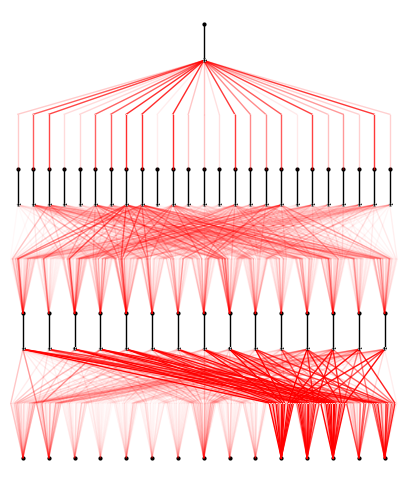

In [74]:
model.plot()